#**Business Case Study: Walmart**

<img src="https://cdn.dribbble.com/userupload/5249948/file/original-af6c722d469e1717d1d130299f33278d.gif" width="20%">

## **About Walmart :**

Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.


## **Business Problem :**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

## **Dataset:**

The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday. The dataset has the following features:

**Dataset link:** Walmart_data.csv

- **User_ID:** User ID
- **Product_ID:** Product ID
- **Gender:** Sex of User
- **Age:** Age in bins
- **Occupation:** Occupation (Masked)
- **City_Category:** Category of the City (A, B, C)
- **StayInCurrentCityYears:** Number of years stay in current city
- **Marital_Status:** Marital Status
- **ProductCategory:** Product Category (Masked)
- **Purchase:** Purchase Amount


#**1. Defining Problem Statement and Analyzing basic metrics**
   1. Observations on shape of data, data types of all the attributes, conversion of categorical attributes to ‘category’ (If required), statistical summary
   2. Non-Graphical Analysis: Value counts and unique attributes
   3. Visual Analysis - Univariate & Bivariate
      - For continuous variable(s): Distplot, countplot, histogram for univariate analysis
      - For categorical variable(s): Boxplot
      - For correlation: Heatmaps, Pairplots

**Importing libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from scipy.stats import binom,norm,geom,uniform,poisson

In [ ]:
# Setting color palette for complete analysis


colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']

sns.set_palette(sns.color_palette(colors))

**Original dataset importing**

In [ ]:
df = pd.read_csv("/content/walmart_data.txt")
#df = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


##  **1.1 Observations on shape of data, data types of all the attributes, conversion of categorical attributes to ‘category’ (If required), statistical summary**

**a. Display the Data Types of Each Column**

In [ ]:
df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,object
Age,object
Occupation,int64
City_Category,object
Stay_In_Current_City_Years,object
Marital_Status,int64
Product_Category,int64
Purchase,int64


**b.Getting shape of data**

In [ ]:
df.shape

(550068, 10)

**c.Check for the missing values and find the number of missing values in each
column**

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


To find where is the missing value :

In [ ]:
# Display rows with missing values
missing_values = df[df.isnull().any(axis=1)]
missing_values


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase


### **Observations:**
There are no missing values

**d.Getting dataset info**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


**e.Getting Statistical Data**

The Current dataset mostly has categorical data, only few columns with numerical data are available

In [ ]:
df.describe(include='all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.000000,550068.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,5,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,0.409653,5.404270,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,0.491770,3.936211,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,0.000000,1.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,5.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,1.000000,8.000000,12054.000000


In [ ]:
df["Purchase"].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


**Observations:**

- The dataset reveals a wide range of purchase behaviors at Walmart.
- The **average transaction amount** is **\$9,263.97**, indicating moderate to high spending.
- A **high standard deviation** of **\$5,023.07** suggests significant variability in customer spending, reflecting a diverse customer base with varying spending capacities.
- The presence of both **low-value** (\$12) and **high-value** (\$23,961) transactions shows that Walmart serves a broad market, offering products across a wide price range from low-cost to premium items.
- This diversity in purchase amounts highlights opportunities for Walmart to implement **targeted marketing** and **pricing strategies** to maximize revenue across different customer segments.

**Summary:**

`The purchase amounts` vary widely, with the minimum recorded purchase being `$12` and the maximum reaching `$23961`. The `median` purchase amount of `$8047` is notably lower than the `mean` purchase amount of `$9264`, indicating a `right-skewed distribution` where a few high-value purchases pull up the mean

**f.Summary statistics for non-numeric columns**:

In [ ]:
df.describe(include=['object'])

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068,550068
unique,3631,2,7,3,5
top,P00265242,M,26-35,B,1
freq,1880,414259,219587,231173,193821


**g.Conversion of categorical attributes to 'category'**

In [ ]:
# List of categorical columns
categorical_columns = ['User_ID','Product_ID','Gender', 'Age', 'Occupation','City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']

# Convert categorical columns to 'category' dtype
df[categorical_columns] = df[categorical_columns].astype('category')
df.dtypes

# Other Way :
# df['Gender'] = df['Gender'].astype('category')
# df['Age'] = df['Age'].astype('category')
# df['Occupation'] = df['Occupation'].astype('category')



,0
User_ID,category
Product_ID,category
Gender,category
Age,category
Occupation,category
City_Category,category
Stay_In_Current_City_Years,category
Marital_Status,category
Product_Category,category
Purchase,int64


In [ ]:
df.describe(include=['category'])

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category
count,550068,550068,550068,550068,550068,550068,550068,550068,550068
unique,5891,3631,2,7,21,3,5,2,20
top,1001680,P00265242,M,26-35,4,B,1,0,5
freq,1026,1880,414259,219587,72308,231173,193821,324731,150933


### **Observations**

**1. User_ID** - Among `5,50,068` transactions there are `5891` unique user_id, indicating same customers buying multiple products.

**2. Product_ID** - Among `5,50,068` transactions there are `3631` unique products,with the product having the code `P00265242` being the `highest seller`, with a maximum of `1,880 units` sold.

**3. Gender** - Out of `5,50,068` transactions, 4,14,259 `(nearly 75%)` were done by male gender indicating a significant disparity in purchase behavior between males and females during the Black Friday event.

**4. Age** - We have `7` unique age groups in the dataset. `26 - 35` Age group has maximum of `2,19,587` transactions. We will analyse this feature in detail in future

**5. Stay_In_Current_City_Years** - Customers with `1` year of stay in current city accounted to maximum of `1,93,821` transactions among all the other customers with (0,2,3,4+) years of stay in current city

**6. Marital_Status** - `59%` of the total transactions were done by `Unmarried Customers` and `41%` by `Married Customers`.

In [ ]:
df.sample(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
480857,1002012,P00006442,M,26-35,4,B,3,1,5,3453
140139,1003650,P00142142,M,26-35,0,A,2,0,1,19415
543207,1005637,P00068842,M,0-17,10,C,2,0,5,8648
140585,1003705,P00004742,M,46-50,7,B,1,1,6,16707
486968,1003065,P00361842,F,18-25,4,A,2,0,15,17084
262985,1004470,P00120242,M,36-45,12,C,3,1,8,6156
445346,1002576,P00039242,M,18-25,17,B,0,0,1,4345
46165,1001120,P00052142,M,18-25,4,A,0,1,8,7781
460255,1004837,P00345842,M,26-35,5,B,2,0,2,9548
238411,1000796,P00120242,M,51-55,6,B,4+,1,8,7886


### **1.2 Non-Graphical Analysis: Value counts and unique attributes** ​

In [ ]:
# Value counts for each column

columns_to_check = ['Product_ID','Gender', 'Age', 'Occupation', 'City_Category',
                    'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']

for column in columns_to_check:
    print(f"\n{column} Value Counts:\n", df[column].value_counts())




Product_ID Value Counts:
 Product_ID
P00265242    1880
P00025442    1615
P00110742    1612
P00112142    1562
P00057642    1470
             ... 
P00068742       1
P00012342       1
P00162742       1
P00091742       1
P00231642       1
Name: count, Length: 3631, dtype: int64

Gender Value Counts:
 Gender
M    414259
F    135809
Name: count, dtype: int64

Age Value Counts:
 Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

Occupation Value Counts:
 Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64

City_Category Value Counts:
 City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

Stay_In_Current_City_Years Value Counts:
 Stay_In_Current_C

In [ ]:
# Unique values for each column

columns_to_check = ['Gender', 'Age', 'Occupation', 'City_Category',
                    'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category']

for column in columns_to_check:
    print(f"\nUnique values in '{column}':\n", df[column].unique())





Unique values in 'Gender':
 ['F', 'M']
Categories (2, object): ['F', 'M']

Unique values in 'Age':
 ['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']
Categories (7, object): ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

Unique values in 'Occupation':
 [10, 16, 15, 7, 20, ..., 18, 5, 14, 13, 6]
Length: 21
Categories (21, int64): [0, 1, 2, 3, ..., 17, 18, 19, 20]

Unique values in 'City_Category':
 ['A', 'C', 'B']
Categories (3, object): ['A', 'B', 'C']

Unique values in 'Stay_In_Current_City_Years':
 ['2', '4+', '3', '1', '0']
Categories (5, object): ['0', '1', '2', '3', '4+']

Unique values in 'Marital_Status':
 [0, 1]
Categories (2, int64): [0, 1]

Unique values in 'Product_Category':
 [3, 1, 12, 8, 5, ..., 10, 17, 9, 20, 19]
Length: 20
Categories (20, int64): [1, 2, 3, 4, ..., 17, 18, 19, 20]


In [ ]:

# Number of unique values for each relevant column

columns_to_check = ['Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
                    'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category', 'Purchase']

for column in columns_to_check:
    print(f"Number of unique values in '{column}':", df[column].nunique())



Number of unique values in 'Product_ID': 3631
Number of unique values in 'Gender': 2
Number of unique values in 'Age': 7
Number of unique values in 'Occupation': 21
Number of unique values in 'City_Category': 3
Number of unique values in 'Stay_In_Current_City_Years': 5
Number of unique values in 'Marital_Status': 2
Number of unique values in 'Product_Category': 20
Number of unique values in 'Purchase': 18105


In [ ]:
#  Convert Marital_Status from 0,1 to Unmarried and Married
df['Marital_Status'] = df['Marital_Status'].replace({0: 'Unmarried', 1: 'Married'})

--------------------------------------------------------------------------------

##**2. Detect Null values and outliers**

Finding first what are the column names :

In [ ]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

**Summary:**

**Numerical Column:**  Purchase (Continuous)

**Categorical Columns:**
- **User_ID:** Represents individual users. (Categorical, but often treated as an identifier rather than a categorical feature)
- **Product_ID**: Represents different products. (Categorical, but often treated as an identifier rather than a categorical feature)
- **Nominal:** User_ID, Product_ID, Gender, Occupation, City_Category,Marital_Status, ProductCategory

- **Ordinal:** Age, Stay_In_Current_City_Years

**a.Find the outliers for every continuous variable in the dataset**

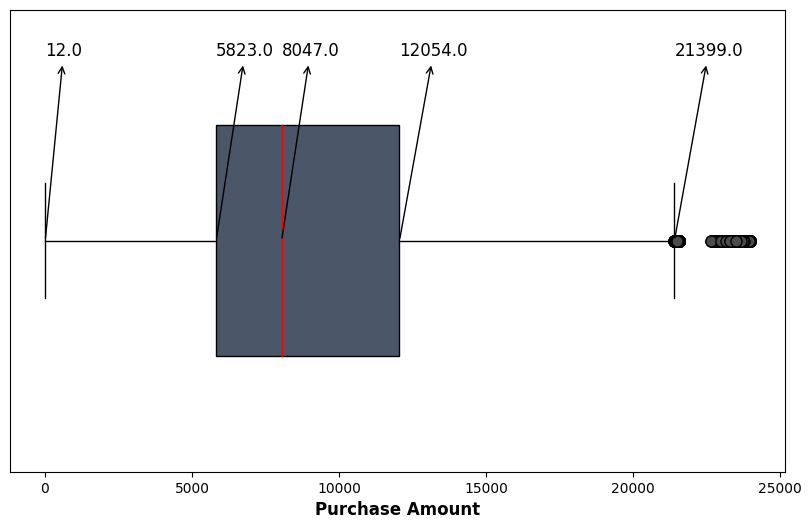

In [ ]:
# Graphical Analysis

sns.reset_defaults()

# Create the figure
fig = plt.figure(figsize=(10, 6))

# Creating the Box Plot
ax1 = fig.add_subplot(111)  # Use a single subplot
boxplot = ax1.boxplot(x=df['Purchase'], vert=False, patch_artist=True, widths=0.5)

# Customizing the Box Plot
colors = ['#495768']  # List of colors for boxes

# Apply color to each box
for box, color in zip(boxplot['boxes'], colors):
    box.set(facecolor=color)

# Customize the median line color
boxplot['medians'][0].set(color='red')

# Customize outlier markers
for flier in boxplot['fliers']:
    flier.set(marker='o', markersize=8, markerfacecolor="#4b4b4c")

# Adding Annotations for the Box Plot
info = [i.get_xdata() for i in boxplot['whiskers']]
median = df['Purchase'].quantile(0.5)

for i, j in info:
    ax1.annotate(text=f"{i:.1f}", xy=(i, 1), xytext=(i, 1.4), fontsize=12,
                 arrowprops=dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))
    ax1.annotate(text=f"{j:.1f}", xy=(j, 1), xytext=(j, 1.4), fontsize=12,
                 arrowprops=dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))

ax1.annotate(text=f"{median:.1f}", xy=(median, 1), xytext=(median + 1, 1.4), fontsize=12,
             arrowprops=dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))

# Final Touches
ax1.set_yticks([])
ax1.set_xlabel('Purchase Amount', fontweight='bold', fontsize=12)

# Display the plot
plt.show()


#### **Calculating the Number of Outliers**

- As seen above, Purchase amount over 21399 is considered as outlier. We will count the number of outliers as below

In [ ]:
len(df.loc[df['Purchase'] > 21399,'Purchase'])

2677

**Approach 1 :**

**Observations**:

- **Outliers**
    
    - There are total of `2677 outliers` which is roughly `0.48%` of the total data present in purchase amount. We will not remove them as it indicates a broad range of spending behaviors during the sale, highlighting the importance of tailoring marketing strategies to both regular and high-value customers to maximize revenue.
    
   

**Approach 2 :** We can clip the data between 5th and 95th Percentile ( Our Approach)

**b.Remove/clip the data between the 5 percentile and 95 percentile**

In [ ]:
df["Purchase"] = np.clip(df["Purchase"],df["Purchase"].quantile(0.05),df["Purchase"].quantile(0.94))

--------------------------------------------------------------------------------

## **3.Data Exploration**

## **3.1 Univariate Analysis:**

**1.Product Amount Analysis**




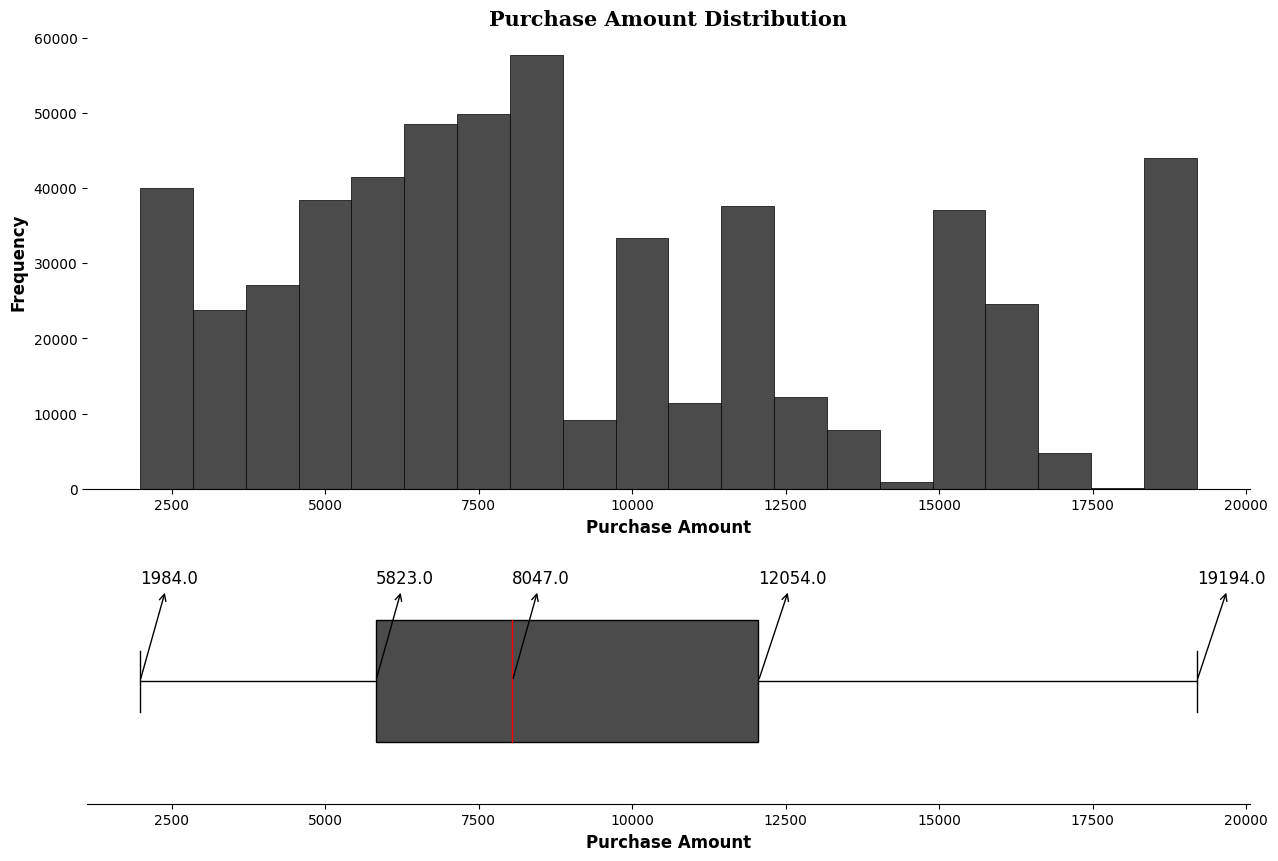

In [ ]:
#setting the plot style

fig = plt.figure(figsize = (15,10))
gs = fig.add_gridspec(2,1,height_ratios=[0.65, 0.35])

                                    #creating purchase amount histogram

ax0 = fig.add_subplot(gs[0,0])

ax0.hist(df['Purchase'],color= '#4b4b4c',linewidth=0.5,edgecolor='black',bins = 20)
ax0.set_xlabel('Purchase Amount',fontsize = 12,fontweight = 'bold')
ax0.set_ylabel('Frequency',fontsize = 12,fontweight = 'bold')

#removing the axis lines
for s in ['top','left','right']:
    ax0.spines[s].set_visible(False)

#setting title for visual
ax0.set_title('Purchase Amount Distribution',{'font':'serif', 'size':15,'weight':'bold'})


                                     #creating box plot for purchase amount

ax1 = fig.add_subplot(gs[1,0])
boxplot = ax1.boxplot(x = df['Purchase'],vert = False,patch_artist = True,widths = 0.5)

# Customize box and whisker colors
boxplot['boxes'][0].set(facecolor='#4b4b4c')

# Customize median line
boxplot['medians'][0].set(color='red')

# Customize outlier markers
for flier in boxplot['fliers']:
    flier.set(marker='o', markersize=8, markerfacecolor= "#4b4b4c")

#removing the axis lines
for s in ['top','left','right']:
    ax1.spines[s].set_visible(False)

#adding 5 point summary annotations
info = [i.get_xdata() for i in boxplot['whiskers']] #getting the upperlimit,Q1,Q3 and lowerlimit

median = df['Purchase'].quantile(0.5) #getting Q2

for i,j in info: #using i,j here because of the output type of info list comprehension

    ax1.annotate(text = f"{i:.1f}", xy = (i,1), xytext = (i,1.4),fontsize = 12,
                 arrowprops= dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))

    ax1.annotate(text = f"{j:.1f}", xy = (j,1), xytext = (j,1.4),fontsize = 12,
                 arrowprops= dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))

#adding the median separately because it was included in info list
ax1.annotate(text = f"{median:.1f}",xy = (median,1),xytext = (median + 1,1.4),fontsize = 12,
            arrowprops= dict(arrowstyle="<-", lw=1, connectionstyle="arc,rad=0"))

#removing y-axis ticks
ax1.set_yticks([])

#adding axis label
ax1.set_xlabel('Purchase Amount',fontweight = 'bold',fontsize = 12)

plt.show()

- **Distribution**

    - Data suggests that the majority of customers spent between `5,823 USD` and `12,054 USD`, with the `median` purchase amount being `8,047 USD`.    
    
    - The lower limit of `12 USD` while the upper limit of `21,399 USD` reveal significant variability in customer spending .However after clipping the data the new upper limit is `19194 USD`

In [ ]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

### **3.2 For Categorical Columns:**

- **Gender,City_Category,Marital_Status:** Creating a pie chart for them
- **Age,Occupation,Stay_In_Current_City_Years,Product_Category :** These columns have more varied entries and hence we can use Bar plot /Countplot for them

### **💼 Gender**,**🏙️ City_Category**,**💍 Marital_Status**


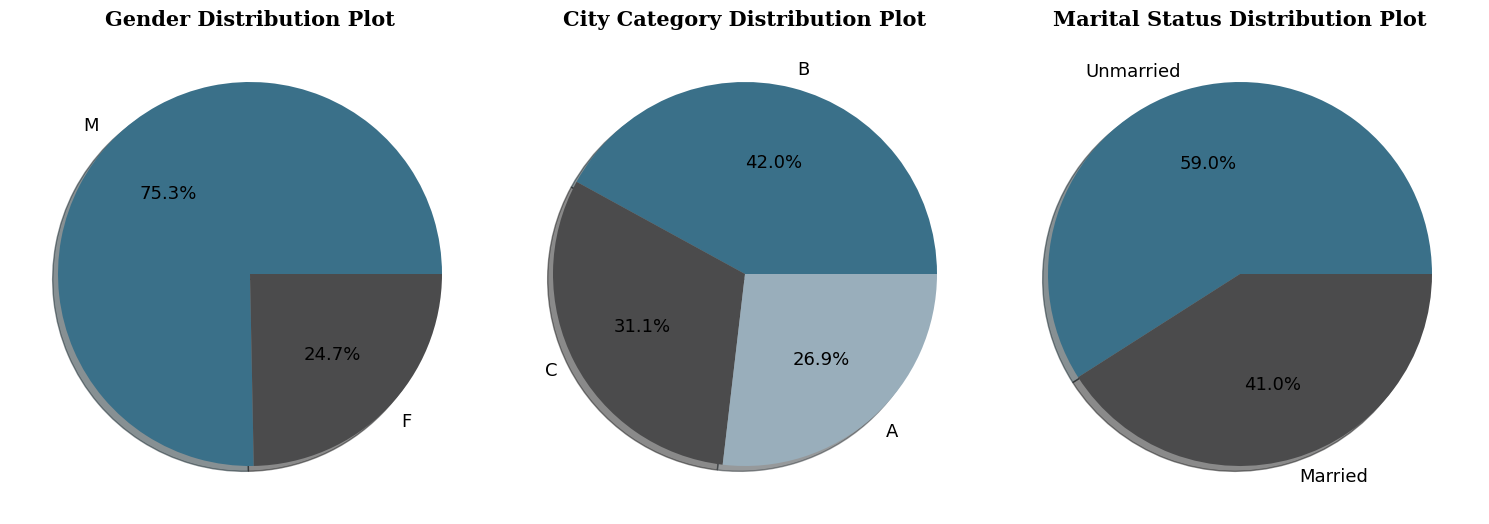

In [ ]:
# Assuming df is your Walmart dataframe
categorical_columns = ['Gender', 'City_Category', 'Marital_Status']

# Colors to use for the pie charts
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']

# Custom grid layout
fig, axes = plt.subplots(1, 3, figsize=(15, 12))

# Titles for each plot
plot_titles = [
    'Gender Distribution Plot',
    'City Category Distribution Plot',
    'Marital Status Distribution Plot'
]

# Pie charts for specified categories
for i, column in enumerate(categorical_columns):
    axes[i].pie(df[column].value_counts().values,
                labels=df[column].value_counts().index,
                autopct='%.1f%%',
                shadow=True,
                colors=colors[:len(df[column].value_counts())],
                textprops={'fontsize': 13, 'color': 'black'})
    axes[i].set_title(plot_titles[i], fontdict={'font':'serif', 'size':15, 'weight':'bold'})

# Adjust layout
plt.tight_layout()
plt.show()


**Observations:**

Here are the key insights in bullet points:

- **Gender Distribution:**
  - Majority is Males with 75.3% male vs 24.7% female.
  - **Strategy:** Focus marketing and product offerings on male customers, with initiatives to attract more female customers.

- **City Category Distribution:**
  - Highest = 42% from Category B followed by  31.1% from Category C, 26.9% from Category A.
  - **Strategy:** Prioritize Category B cities with targeted campaigns; explore growth opportunities in Categories A and C.

- **Marital Status Distribution:**
  - Slight majority with 59% unmarried, 41% married.
  - **Strategy:** Tailor products and promotions for singles and family-oriented options for married customers.



### **📆 Age**, **💼 Occupation**, **🏠 Stay_In_Current_City_Years**, **🛒 Product_Category**


### **📆  Age Distribution:**

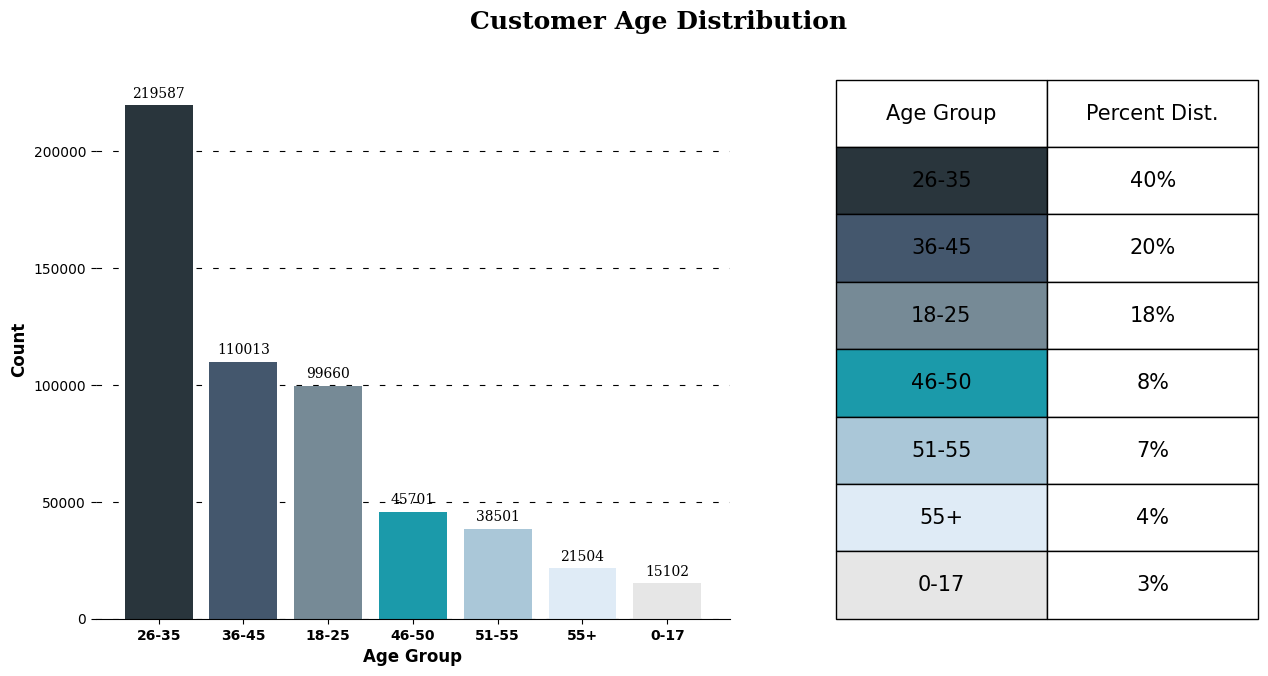

In [ ]:
# Setting the plot style
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[0.6, 0.4])

# Creating bar chart for age distribution
ax0 = fig.add_subplot(gs[0, 0])
temp = df['Age'].value_counts()

# Using the new color palette
color_map = ['#29353C', '#44576D', '#768A96', '#1b9aaa','#AAC7D8', '#DFEBF6', '#E6E6E6',"#ee6c4d" ]
ax0.bar(x=temp.index, height=temp.values, color=color_map[:len(temp)], zorder=2)

# Adding the value counts
for i in temp.index:
    ax0.text(i, temp[i] + 5000, temp[i], {'font': 'serif', 'size': 10}, ha='center', va='center')

# Adding grid lines
ax0.grid(color='black', linestyle='--', axis='y', zorder=0, dashes=(5, 10))

# Removing the axis lines
for s in ['top', 'left', 'right']:
    ax0.spines[s].set_visible(False)

# Adding axis labels
ax0.set_ylabel('Count', fontweight='bold', fontsize=12)
ax0.set_xlabel('Age Group', fontweight='bold', fontsize=12)
ax0.set_xticklabels(temp.index, fontweight='bold')

# Creating an info table for age
ax1 = fig.add_subplot(gs[0, 1])
age_info = [['26-35', '40%'], ['36-45', '20%'], ['18-25', '18%'], ['46-50', '8%'],
            ['51-55', '7%'], ['55+', '4%'], ['0-17', '3%']]

# Updating the colors in the table to match the new palette
color_2d = [['#29353C', '#FFFFFF'], ['#44576D', '#FFFFFF'], ['#768A96', '#FFFFFF'], ['#1b9aaa', '#FFFFFF'],
            ['#AAC7D8', '#FFFFFF'], ['#DFEBF6', '#FFFFFF'], ['#E6E6E6', '#FFFFFF']]

table = ax1.table(cellText=age_info, cellColours=color_2d, cellLoc='center',
                  colLabels=['Age Group', 'Percent Dist.'], colLoc='center', bbox=[0, 0, 1, 1])

table.set_fontsize(15)

# Removing axis
ax1.axis('off')

# Setting title for visual
fig.suptitle('Customer Age Distribution', font='serif', size=18, weight='bold')

plt.show()


### **Observations:**

1. **Customer Age Distribution**:
   - The age group `26-35` is the largest customer segment, representing `40%` of the total customers, with a count of `219,587`.
   - The second-largest age group is `36-45`, making up `20%` of the customer base, with a count of `110,013`.
   - The `18-25` age group follows closely behind, accounting for `18%` of customers, with `99,660` individuals.
   - The remaining age groups have smaller customer segments:
     - `46-50`: `8%` (45,701 customers)
     - `51-55`: `7%` (38,501 customers)
     - `55+`: `4%` (21,504 customers)
     - `0-17`: `3%` (15,102 customers)

### **Business Insights:**
1. **Target Marketing**:
   - The `26-35` age group is the dominant segment, indicating a strong potential for targeted marketing and promotional activities. Retailers like Walmart should focus on products, discounts, and marketing strategies that appeal to this age group.
   - Since the `36-45` and `18-25` age groups are also significant, they should be secondary targets for promotional efforts, with tailored marketing campaigns that address their specific needs and preferences.

2. **Product Assortment and Inventory Planning**:
   - Given the high concentration of customers in the `26-35` and `36-45` age groups, product assortments should align with the preferences and purchasing behavior of these demographics. This could include items related to family life, career growth, technology, and lifestyle products.
   - For the `18-25` segment, products related to education, early career, fashion, and entertainment might resonate well.

3. **Customer Retention Strategies**:
   - To retain customers within the `26-35` age group, loyalty programs and personalized offers could be effective, encouraging repeat purchases.
   - For the `36-45` and `18-25` segments, strategies such as flexible payment options, memberships, or bundling relevant products can boost retention.

4. **Expansion Opportunities**:
   - The lower percentages in the `46-50`, `51-55`, `55+`, and `0-17` age groups suggest potential areas for growth. Understanding why these groups are underrepresented could lead to new strategies for attracting them, such as specific product offerings or tailored marketing campaigns.

5. **Demographic Focus**:
   - **The data indicates that Walmart’s customer base is skewed towards younger and middle-aged adults.** This suggests a focus on demographics that are likely in their working years, possibly with young families. Understanding the lifestyle and purchasing behavior of these groups will be critical for business decisions.

These insights can help in developing a more focused and effective strategy for customer engagement, inventory management, and marketing initiatives.

### **🏠 Stay_In_Current_City_Years Distribution**

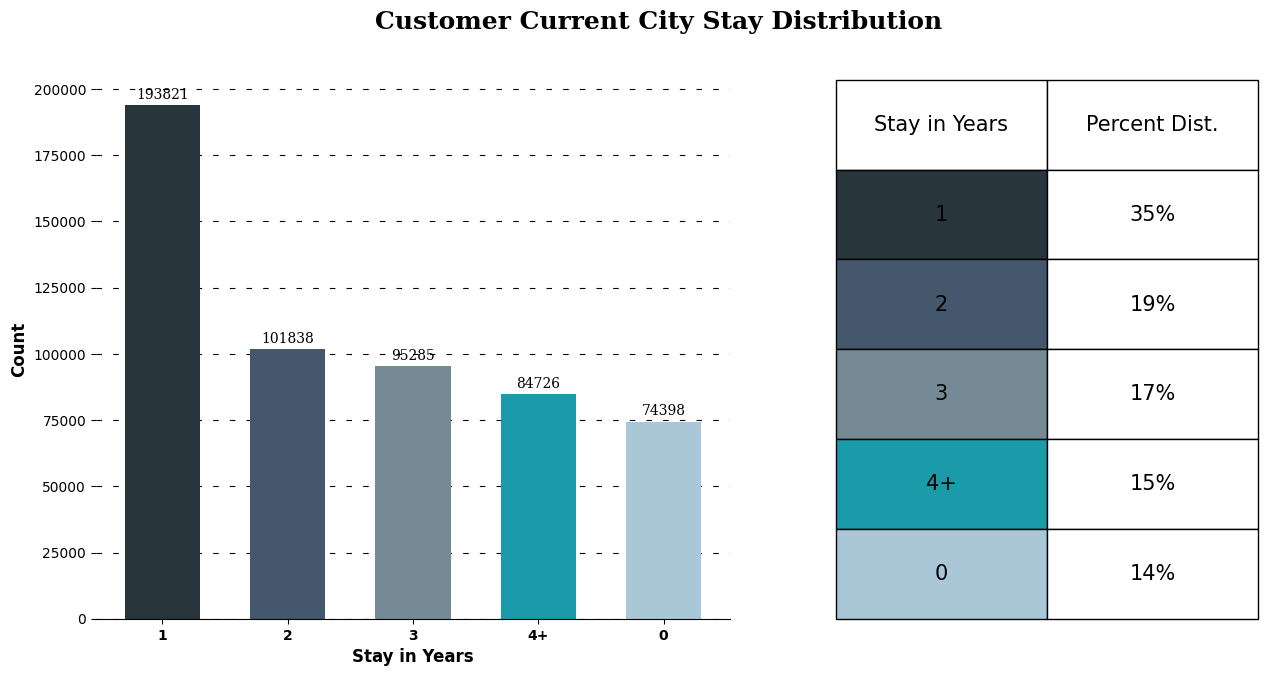

In [ ]:
# Setting the plot style
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[0.6, 0.4])

# New color palette
color_map = ['#29353C', '#44576D', '#768A96', '#1b9aaa', '#AAC7D8', '#DFEBF6', '#E6E6E6', "#ee6c4d"]

# Creating bar chart for Customer Stay In Current City
ax1 = fig.add_subplot(gs[0, 0])
temp = df['Stay_In_Current_City_Years'].value_counts()
ax1.bar(x=temp.index, height=temp.values, color=color_map[:len(temp)], zorder=2, width=0.6)

# Adding the value counts
for i in temp.index:
    ax1.text(i, temp[i] + 4000, temp[i], {'font': 'serif', 'size': 10}, ha='center', va='center')

# Adding grid lines
ax1.grid(color='black', linestyle='--', axis='y', zorder=0, dashes=(5, 10))

# Removing the axis lines
for s in ['top', 'left', 'right']:
    ax1.spines[s].set_visible(False)

# Adding axis labels
ax1.set_ylabel('Count', fontweight='bold', fontsize=12)
ax1.set_xlabel('Stay in Years', fontweight='bold', fontsize=12)
ax1.set_xticklabels(temp.index, fontweight='bold')

# Creating an info table for Customer Stay In Current City
ax2 = fig.add_subplot(gs[0, 1])
stay_info = [['1', '35%'], ['2', '19%'], ['3', '17%'], ['4+', '15%'], ['0', '14%']]
color_2d = [color_map[i] if i < len(color_map) else color_map[-1] for i in range(len(stay_info))]

# Adjusting cell colors for the table
cell_colors = [[color_2d[i], '#FFFFFF'] for i in range(len(stay_info))]

table = ax2.table(cellText=stay_info, cellColours=cell_colors, cellLoc='center',
                  colLabels=['Stay in Years', 'Percent Dist.'], colLoc='center', bbox=[0, 0, 1, 1])

table.set_fontsize(15)

# Removing axis
ax2.axis('off')

# Setting title for visual
fig.suptitle('Customer Current City Stay Distribution', font='serif', size=18, weight='bold')

plt.show()


### **Business Insights:**

1. **Customer Loyalty**:
   - 35% of customers have stayed in their current city for `1 year`, indicating a strong base of new residents. Walmart can build loyalty with targeted offers and city-specific promotions.
   - Lower representation (15%) of customers who stayed `4+ years` suggests an opportunity to enhance long-term customer retention, possibly through loyalty programs.

2. **Targeted Marketing**:
   - Significant segments with `2-3 years` of stay (36% combined) might be settling down. Walmart could focus on products and services catering to more stable, family-oriented lifestyles.
   - The `0 years` group (14%) likely consists of newcomers or transients; targeting them with essential items and newcomer-friendly offers could be effective.

3. **Expansion Opportunities**:
   - The distribution suggests Walmart is popular in areas with high population turnover. There may be opportunities to expand in growing cities and cater specifically to newcomers.

4. **Product Assortment**:
   - Focus on essentials for newer residents (0-1 year) and more established lifestyle products for long-term residents (`4+ years`).

5. **Community Engagement**:
   - Engaging both newcomers and long-term residents through community events and localized initiatives can enhance Walmart's connection with its customer base.

### **💼 Top 10 Occupations**

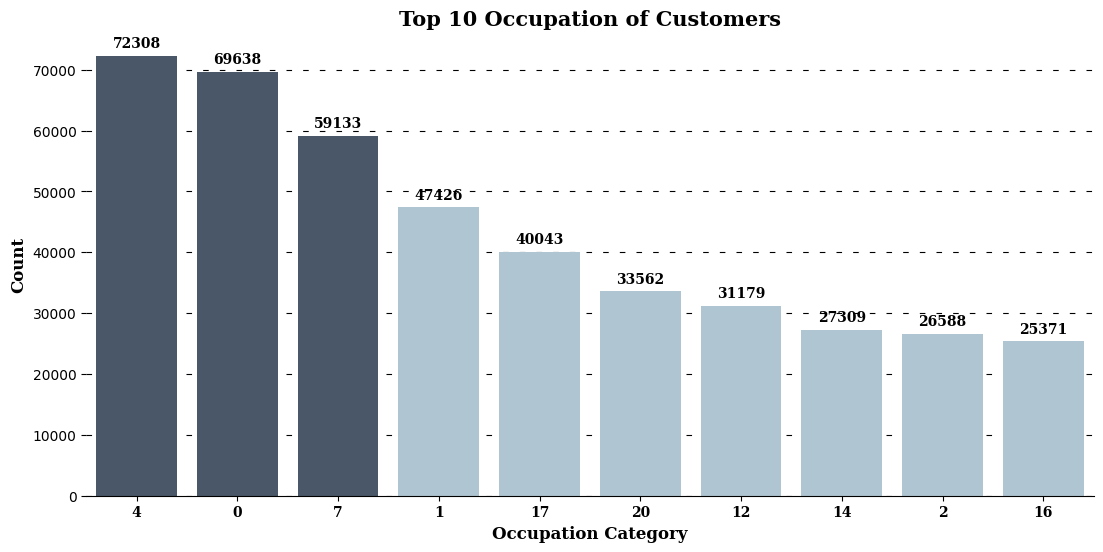

In [ ]:
temp = df['Occupation'].value_counts()[0:10].index

# Setting the plot style
plt.figure(figsize=(13, 6))

# Creating the plot
ax = sns.countplot(data=df[df['Occupation'].isin(temp)], x='Occupation',
                   order=temp,palette=['#44576D']*3 + ['#AAC7D8']*7, zorder=2)

# Adding value counts
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 2000, int(height),
            {'font':'serif', 'size':10, 'weight':'bold'},
            ha='center', va='center')

# Setting grid style
ax.grid(color='black', linestyle='--', axis='y', zorder=0, dashes=(5, 10))

# Customizing the axis labels
ax.set_xlabel('Occupation Category', {'font': 'serif', 'size': 12, 'weight': 'bold'})
ax.set_ylabel('Count', {'font': 'serif', 'size': 12, 'weight': 'bold'})
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold', fontfamily='serif')

# Removing the axis lines
for s in ['top', 'left', 'right']:
    ax.spines[s].set_visible(False)

# Adding title to the visual
ax.set_title('Top 10 Occupation of Customers', {'font': 'serif', 'size': 15, 'weight': 'bold'})

plt.show()


### **Business Insight**


- **Top Occupation Categories**: Occupations 4, 0, and 7 have the highest customer counts, indicating potential for focused marketing.
- **Targeted Promotions**: Occupations 14, 2, and 16 are less represented, suggesting an opportunity for targeted promotions to attract these groups.


### **🛒 Top 10 Product_Category and Product_Id**

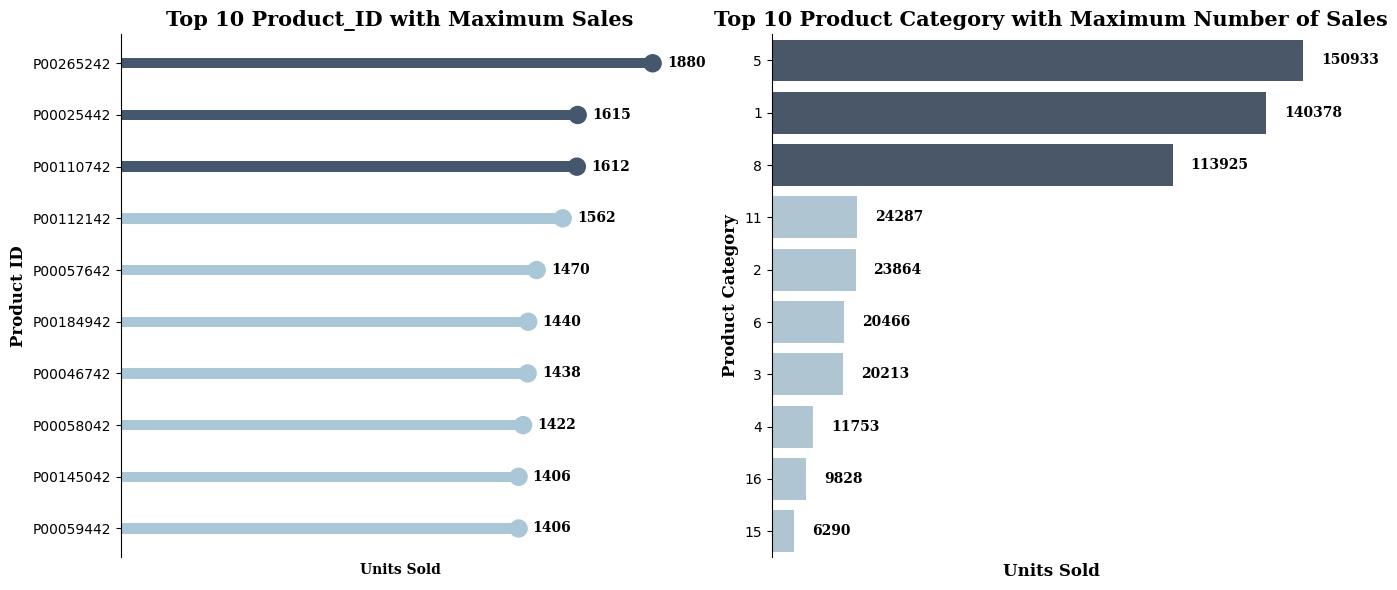

In [ ]:
# Setting the plot style
fig = plt.figure(figsize=(14, 6))  # Adjust the width for side-by-side plots
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])  # 1 row, 2 columns

# Top 10 Product_ID Sales
ax1 = fig.add_subplot(gs[0, 0])

temp = df['Product_ID'].value_counts()[0:10]
temp = temp.iloc[-1:-11:-1]  # Reversing the list

# Color palette for Product_ID plot
color_map = ['#44576D'] * 3 + ['#AAC7D8'] * 7

# Creating the barh plot with scatter points
ax1.barh(y=temp.index, width=temp.values, height=0.2, color=color_map[::-1])
ax1.scatter(y=temp.index, x=temp.values, s=150, color=color_map[::-1])

# Removing x-axis
ax1.set_xticks([])

# Adding label to each bar
for y, x in zip(temp.index, temp.values):
    ax1.text(x + 50, y, str(x), {'font': 'serif', 'size': 10, 'weight': 'bold'}, va='center')

# Removing the axis lines
for s in ['top', 'bottom', 'right']:
    ax1.spines[s].set_visible(False)

# Adding axis labels
ax1.set_xlabel('Units Sold', {'font': 'serif', 'size': 10, 'weight': 'bold'})
ax1.set_ylabel('Product ID', {'font': 'serif', 'size': 12, 'weight': 'bold'})

# Creating the title
ax1.set_title('Top 10 Product_ID with Maximum Sales',
              {'font': 'serif', 'size': 15, 'weight': 'bold'})

# Top 10 Product Category Sales using countplot
ax2 = fig.add_subplot(gs[0, 1])

# Getting top 10 product categories in descending order
top_categories = df['Product_Category'].value_counts().iloc[:10]

# Color palette for Product_Category plot, ensuring top 3 are darker
color_map_category = ['#44576D'] * 3 + ['#AAC7D8'] * 7

# Using Seaborn's countplot for Product Category in descending order
sns.countplot(y=df['Product_Category'], order=top_categories.index, palette=color_map_category, ax=ax2)

# Adding labels to each bar
for i, v in enumerate(top_categories.values):
    ax2.text(v + 5000, i, str(v), va='center', fontdict={'font':'serif', 'size':10, 'weight':'bold'})

# Removing the axis lines
ax2.set_xticks([])
for s in ['top', 'bottom', 'right']:
    ax2.spines[s].set_visible(False)

# Adding axis labels
ax2.set_xlabel('Units Sold', {'font': 'serif', 'size': 12, 'weight': 'bold'})
ax2.set_ylabel('Product Category', {'font': 'serif', 'size': 12, 'weight': 'bold'})

# Creating the title
ax2.set_title('Top 10 Product Category with Maximum Number of Sales',
              {'font': 'serif', 'size': 15, 'weight': 'bold'})

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


### **Business Insights**

**1. Top 10 Products Sold** - The top-selling products during Walmart's Black Friday sales are characterized by a `relatively small variation` in sales numbers, indicating consistent customer demand across these items. Walmart's diverse product offerings appeal to a broad customer base.


**2. Top 10 Product Categories** - Categories `5,1 and 8` have significantly outperformed other categories with combined Sales of nearly `75%` of the total sales highlighting their strong customer preference. Focusing on these categories could maximize revenue.

**3. Strategic Focus** - Maintain balanced inventory and marketing for top-selling products while prioritizing dominant categories for promotions and stock management to capitalize on customer demand.

## **3.2 Bivariate Analysis:**

### **Purchase Patterns Against All the Categorical Features**

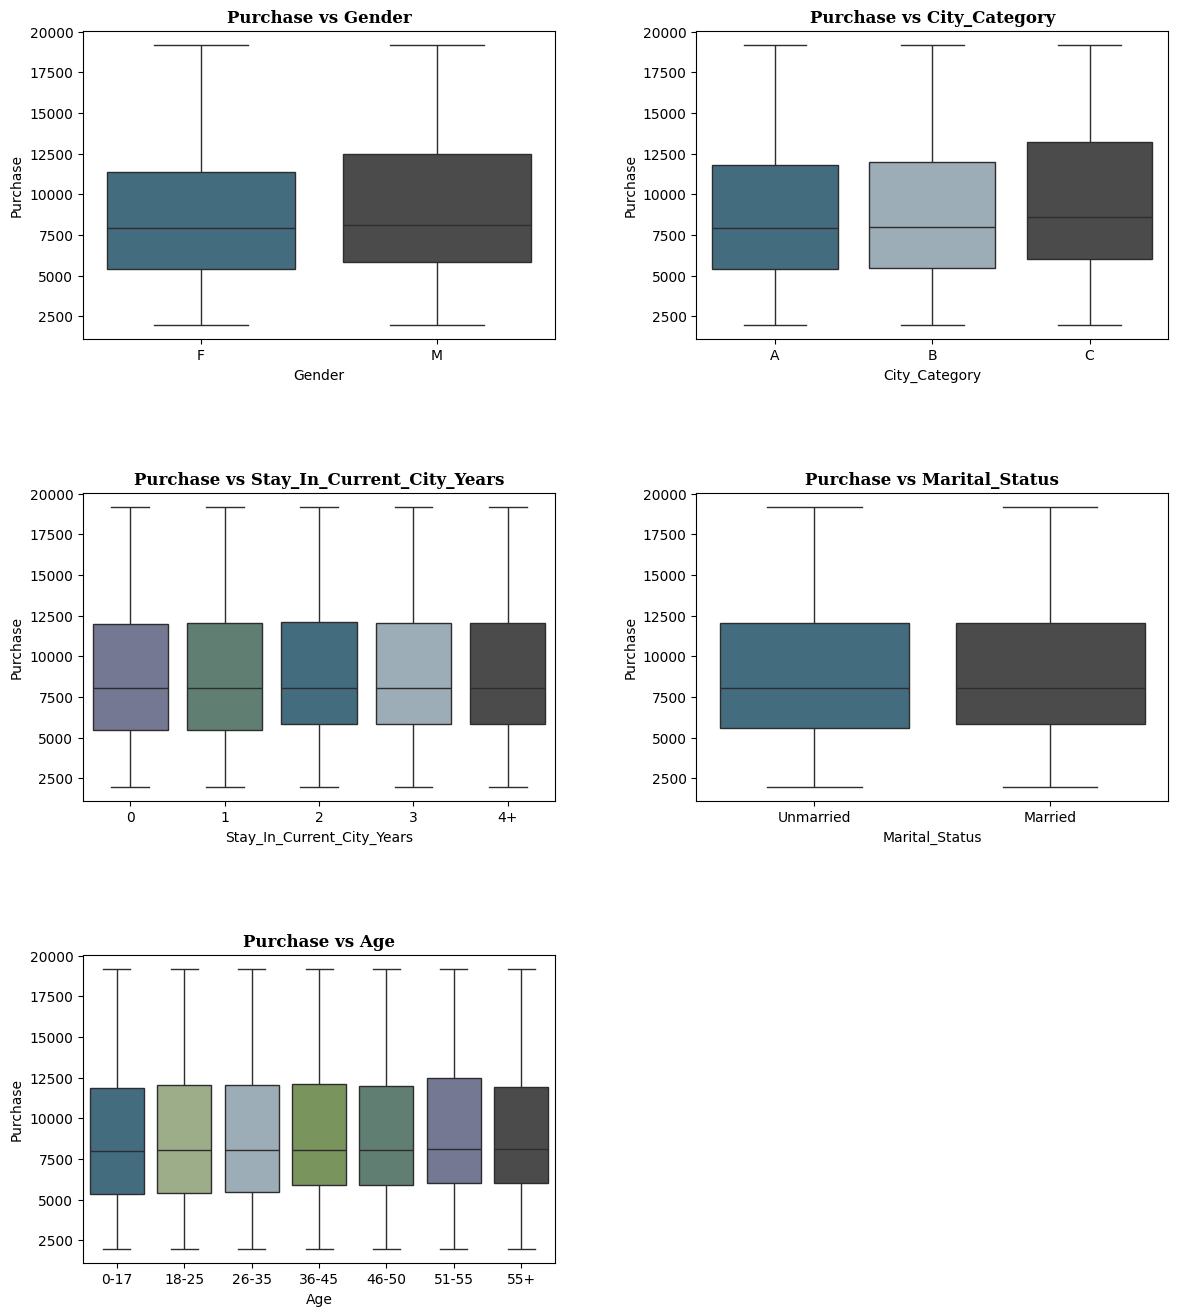

In [ ]:
# Identifying the categorical columns
categorical_columns = ['Gender', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status','Age']

# Custom color palette
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']

# Setting up the plotting area
plt.figure(figsize=(14, 16))

# Generate a boxplot for each categorical column against the Purchase column
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, i)

    # Create a color palette mapping for the current categorical column
    unique_values = df[col].unique()
    color_dict = dict(zip(unique_values, colors[:len(unique_values)]))

    sns.boxplot(x=col, y='Purchase', data=df, palette=color_dict)

    # Apply the title with custom font settings
    plt.title(f'Purchase vs {col}', font='serif', size=12, weight='bold')



# Adjust spacing between rows and columns
plt.subplots_adjust(hspace=0.5, wspace=0.3)


plt.show()

### **Observations:**

**1. Purchase Vs Age of Customers:**
- **Consistency Across Age Groups**:
   - The median purchase amount is fairly consistent across all age groups, falling around the 8,000-10,000 range. This indicates that, on average, customers in different age groups spend a similar amount.
-  **Purchase Variation**:
   - The spread of purchase amounts (interquartile range) is also consistent across age groups, suggesting that there isn't a significant difference in spending behavior between different age categories. The full range of spending (from the minimum to the maximum) is broad, but this is consistent across all age groups.

**2.Purchase VS Gender:**
- Median Purchase amount, min and max Purchase amount are higher for Males as compared to Females on Black Friday Sales

**3.Purchase VS ity Category:**
- Median Purchase amount, min and max Purchase amount are higher for City Category C as compared to A,B which are almost consistent

For all remaining variables Purchase Amount does not vary much in distribution .






**3.2.a. What products are different age groups buying?**

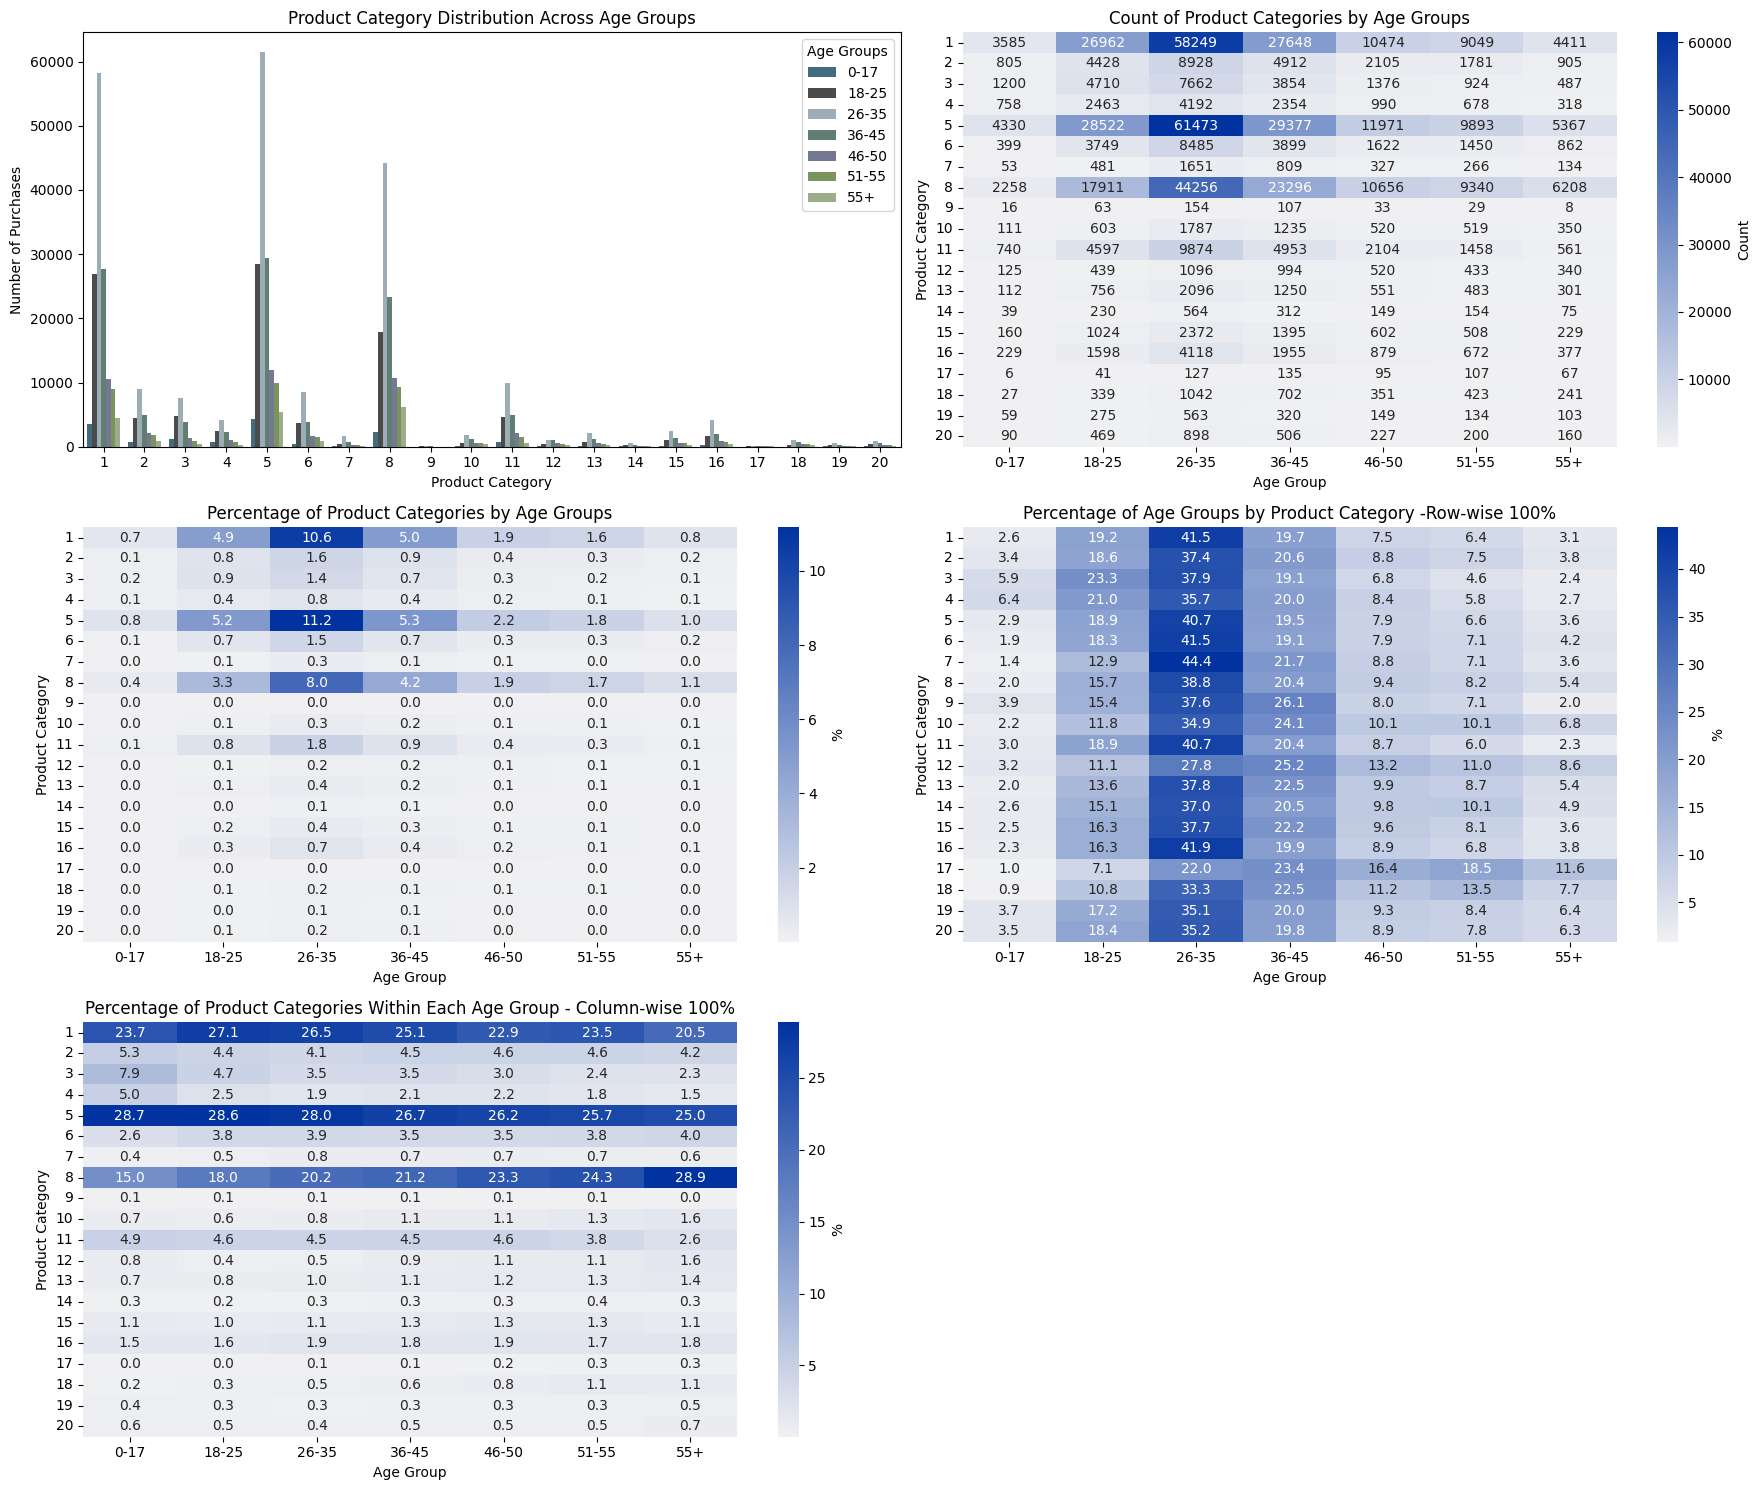

In [ ]:
# Define the color palette
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']

# Create a figure with 5 subplots
fig, axs = plt.subplots(3, 2, figsize=(18, 15))

# First plot - Countplot
sns.countplot(data=df, x='Product_Category', hue='Age', palette=colors, ax=axs[0, 0])
axs[0, 0].set_title('Product Category Distribution Across Age Groups')
axs[0, 0].set_xlabel('Product Category')
axs[0, 0].set_ylabel('Number of Purchases')
axs[0, 0].legend(title='Age Groups')

# Second plot - Heatmap of counts
crosstab = pd.crosstab(df['Product_Category'], df['Age'])
cmap = sns.light_palette("#0033A0", as_cmap=True)
sns.heatmap(crosstab, annot=True, cmap=cmap, fmt='d', cbar_kws={'label': 'Count'}, ax=axs[0, 1])
axs[0, 1].set_title('Count of Product Categories by Age Groups')
axs[0, 1].set_xlabel('Age Group')
axs[0, 1].set_ylabel('Product Category')

# Third plot - Global percentages
percentages = crosstab.div(crosstab.sum().sum(), axis=1) * 100
sns.heatmap(percentages, annot=True, cmap=cmap, fmt='.1f', cbar_kws={'label': '%'}, ax=axs[1, 0])
axs[1, 0].set_title('Percentage of Product Categories by Age Groups')
axs[1, 0].set_xlabel('Age Group')
axs[1, 0].set_ylabel('Product Category')

# Fourth plot - Row-wise percentages (normalized by product category)
# Result: The percentages in each row will sum to 100%. This tells you how different age groups contribute to the total purchases of a specific product category

row_percentages = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
sns.heatmap(row_percentages, annot=True, cmap=cmap, fmt='.1f', cbar_kws={'label': '%'}, ax=axs[1, 1])
axs[1, 1].set_title('Percentage of Age Groups by Product Category -Row-wise 100%')
axs[1, 1].set_xlabel('Age Group')
axs[1, 1].set_ylabel('Product Category')

# Fifth plot - Column-wise percentages (normalized by age group)
# Result: The percentages in each column will sum to 100%. This tells you how each product category contributes to the total purchases within each specific age group

column_percentages = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
sns.heatmap(column_percentages, annot=True, cmap=cmap, fmt='.1f', cbar_kws={'label': '%'}, ax=axs[2, 0])
axs[2, 0].set_title('Percentage of Product Categories Within Each Age Group - Column-wise 100%')
axs[2, 0].set_xlabel('Age Group')
axs[2, 0].set_ylabel('Product Category')

# Hide the empty subplot (if needed)
fig.delaxes(axs[2, 1])

# Adjust layout to make it prettier
plt.tight_layout()

# Display the combined figure
plt.show()


**Interpretation of 3rd plot - Percentages of Product Categories by Age Groups**:

The percentages in each cell of the heatmap are calculated based on the entire dataset rather than being normalized by row (Product Category) or column (Age Group). This means that:

**Cell Values**: Each cell shows the percentage of total transactions across the entire dataset that corresponds to a particular combination of product category and age group.
**Rows:** The percentages in each row (representing a product category) don't sum to 100% because they represent the distribution of that product category across different age groups in the context of the total number of transactions in the dataset.

**Example Explanation:**
Let's take Product Category 17 as an example:

**Product Category 17, Age Group 46-50:** The percentage might be very low, say 0.3%. This means that 0.3% of all transactions in the entire dataset come from customers aged 46-50 buying products in Category 17.

### **Observations**:
**1. Product Categories 5, 1, and 8** are indeed among the highest in terms of the number of purchases across various age groups.
   - **Product Category 5**: Shows a high number of purchases across almost all age groups, especially in the 26-35 ,18-25 , 36-45 age ranges.
   - **Product Category 1**: Similarly, it has a large number of purchases, particularly in the 26-35 ,18-25 , 36-45 age ranges.
   - **Product Category 8**: Also has high purchase counts, with notable peaks in the younger age groups.

**Other Major Significant Product Categories (other than 5,1,8) for each Age Group :**

**For Age group 26-35,18-25,36-45:** Is driving `Maximum sales` through Product Categories `5,1,8` with a very high count . For this age groups the other major significant product categories are `3,11,2,6`in that order

**Product Category 17:**
- **Observation**:
  - The percentages for **Product Category 17** are slightly higher than Categories 19 and 20 but still very low across the older age groups (46-50, 51-55, 55+), with each showing around **0.1% - 0.4%**.
  
- **Interpretation**:
  - **Low Engagement**: This indicates minimal engagement from the older age groups, suggesting that Product Category 17 is not a primary choice for these demographics or any demographics.
  - **Potential Niche Product**: While slightly more popular than Categories 19 and 20, it still appears to be a product with limited appeal. It might serve a niche purpose, but it’s not a strong performer overall.
  - **Marketing Consideration**: Walmart might want to explore why this category performs poorly among older customers—perhaps by conducting surveys or focus groups to understand the underlying reasons—and determine if there’s a potential to increase its appeal.



### **Business Insight:**
The high purchase volumes in Product Categories 5, 1, and 8 across multiple age groups indicate that these categories are core products that drive a significant portion of sales. Businesses should focus on maintaining a strong inventory for these products, consider promoting them more aggressively, and possibly explore related products that can be bundled or marketed together to capitalize on their popularity.



### Overall Insight for Higher Age Groups:
- **Low Relevance or Appeal**: Product Categories 19, 20, and 17 are not appealing to older customers, as evidenced by their negligible percentage contributions.
- **Strategic Focus**: Walmart should likely not focus on these categories for the 46-50, 51-55, and 55+ age groups unless there’s a clear strategy to reposition or revamp these products to better meet the needs of these consumers.

Additionally, understanding why these specific categories resonate across age groups could provide valuable insights for developing new products or improving existing ones.


### **3.2.b. Is there a relationship between age, marital status, and the amount spent?**

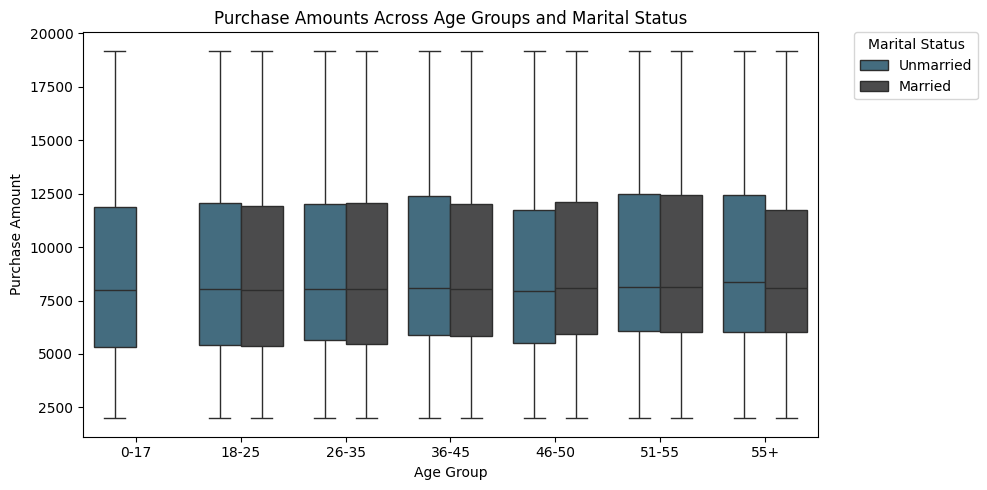

In [ ]:

# Set the custom color palette
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']
sns.set_palette(sns.color_palette(colors))

# Plotting
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Age', y='Purchase', hue='Marital_Status', palette=colors)
plt.title('Purchase Amounts Across Age Groups and Marital Status')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')

# Position the legend outside the plot on the right side
plt.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()



### **1. Similar Spending Patterns Across Marital Status:**
   - Across most age groups, there isn't a significant difference in the median purchase amount between unmarried and married individuals.
   - This suggests that marital status does not strongly influence the spending habits within the same age group.

### **2. Age Group 0-17:**
   - No married Individuals in this Age group however comparable spending pattern /distribution to different age groups

### **3. Wide Purchase Range in All Age Groups:**
   - The wide range of purchase amounts within each age group indicates diverse spending behaviors.
   - This suggests that within each demographic, there are segments of high spenders who might be worth identifying and targeting with premium products or personalized offers.

### **4. Higher and Lower spending amongst Unmarried Individuals:**
   - Age groups `36-45 and 55+` has `Unmarried Individuals` where the upper limit of spending is higher . These age ranges are spending more as compared to Married counterparts
   - Marketing strategies for these age groups should be tailored focusing on products that appeal  to these demographics.
   - Age group `46-50` see higher spending amongst `Married Individuals` including `higher Mean Purchase`. Target them for premium couple products.

### **5. Strategic Recommendations:**
   - **Targeted Campaigns:** Develop age-specific marketing campaigns, particularly focusing on the 18-35 demographic, who appear to have slightly higher spending habits.
   - **Product Bundling:** Introduce product bundles or loyalty programs that appeal to both married and unmarried customers across these age groups, as their spending behavior is quite similar.
   - **High-Value Segments:** Identify and segment out the high spenders within each age group for targeted upselling opportunities.

### **Conclusion:**
While marital status doesn't seem to play a major role in purchase behavior across age groups, age itself does have some influence. This insight can help in crafting marketing and sales strategies that are more age-focused rather than based on marital status.

### **3.2.c. Are there preferred product categories for different genders?**

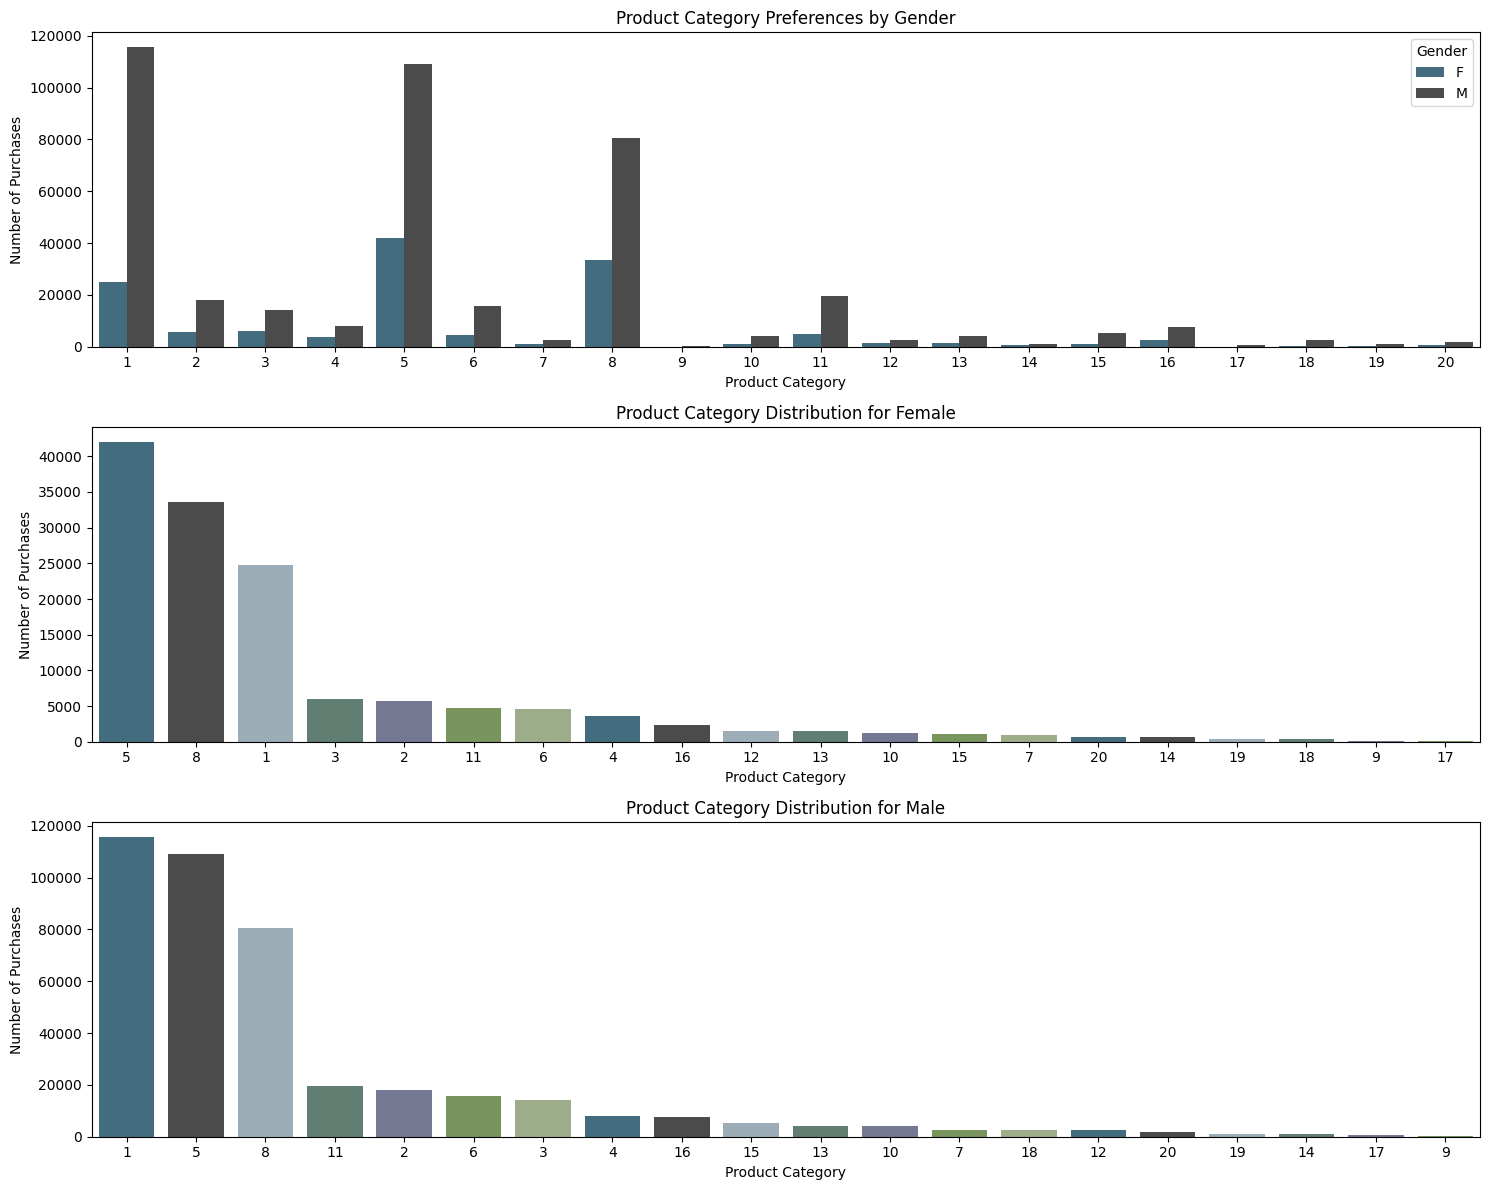

In [ ]:
# Define the color palettes
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']
hue_colors = colors[:2]  # Use the first two colors for Gender

# Filter data by gender
df_female = df[df['Gender'] == 'F']
df_male = df[df['Gender'] == 'M']

# Calculate the count of each Product Category for females and males
female_counts = df_female['Product_Category'].value_counts().sort_values(ascending=False)
male_counts = df_male['Product_Category'].value_counts().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(15, 12))

# Subplot 1: Countplot for Product Categories by Gender
plt.subplot(3, 1, 1)
sns.countplot(data=df, x='Product_Category', hue='Gender', palette=hue_colors)
plt.title('Product Category Preferences by Gender')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.legend(title='Gender')

# Subplot 2: Countplot for Product Categories for Female (sorted)
plt.subplot(3, 1, 2)
sns.countplot(data=df_female, x='Product_Category', palette=colors, order=female_counts.index)
plt.title('Product Category Distribution for Female')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')

# Subplot 3: Countplot for Product Categories for Male (sorted)
plt.subplot(3, 1, 3)
sns.countplot(data=df_male, x='Product_Category', palette=colors, order=male_counts.index)
plt.title('Product Category Distribution for Male')
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')

plt.tight_layout()
plt.show()



### **Business Insights Based on the Product Category vs Gender Analysis:**

1. **Dominant Product Categories:**
   - **Product Categories 1, 5, and 8** are the top three categories across both genders, with Category 1 being the most purchased by males and Category 5 leading among females.
   - **Product Category 1** has a significantly higher number of purchases by males compared to females.
   - **Product Category 5** is popular among both genders but shows a higher count among females.

2. **Gender-Specific Preferences:**
   - **Males** have a higher preference for **Product Categories 5, 8,1 and 11**.
   - **Females** show a stronger preference for **Product Categories 3, 5** `compared to males`.
   - **Product Category 8** is also popular among both genders, but males have a significantly higher number of purchases ( Volume ).

3. **Niche Product Categories:**
   - Categories like **13, 15, 16, 18, and 19** have very low purchase counts, suggesting that they are niche products or less popular during Black Friday sales.



## **4.How does gender affect the amount spent?**

### **Purchase Amount Vs Gender:**

In [ ]:
#creating a df for purchase amount vs gender
temp = df.groupby('Gender')['Purchase'].agg(['sum','count']).reset_index()

#calculating the amount in billions
temp['sum_in_billions'] = round(temp['sum'] / 10**9,2)

#calculationg percentage distribution of purchase amount
temp['%sum'] = round(temp['sum']/temp['sum'].sum(),3)

#calculationg per purchase amount
temp['per_purchase'] = round(temp['sum']/temp['count'])

#renaming the gender
temp['Gender'] = temp['Gender'].replace({'F':'Female','M':'Male'})

temp

,Gender,sum,count,sum_in_billions,%sum,per_purchase
0,Female,1185650125,135809,1.19,0.233,8730.0
1,Male,3901875115,414259,3.90,0.767,9419.0


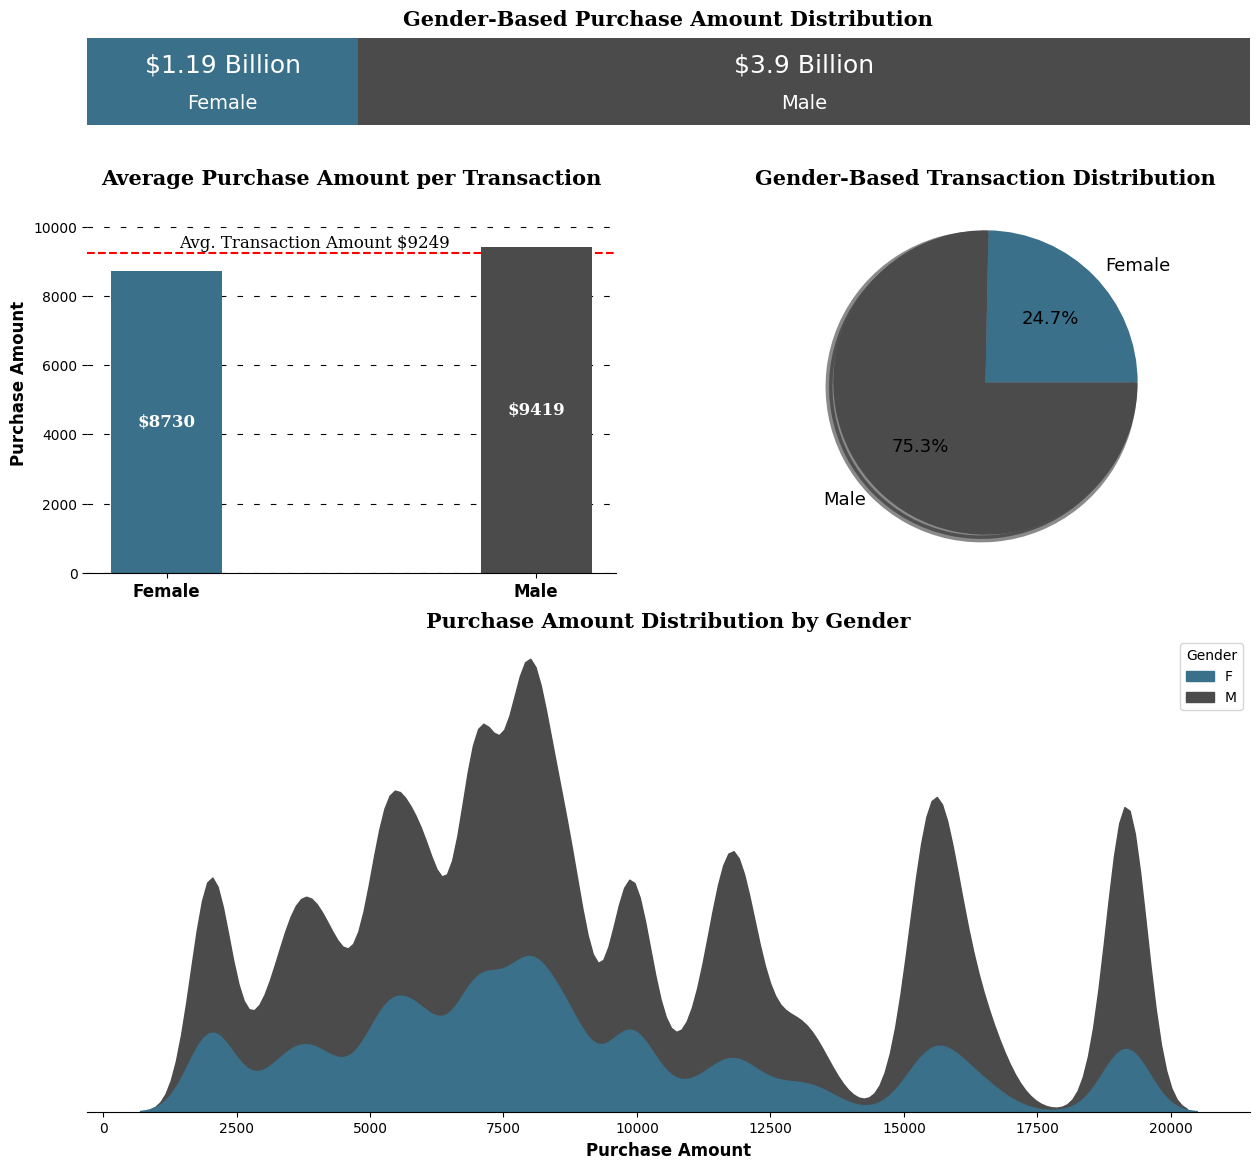

In [ ]:
# Setting the plot style
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[0.10, 0.4, 0.5])

# Define the color palette
colors = ["#3A7089", "#4b4b4c", '#99AEBB', '#5C8374', '#6F7597', '#7A9D54', '#9EB384']

# Distribution of Purchase Amount
ax = fig.add_subplot(gs[0, :])

# Plotting the visual
ax.barh(temp.loc[0, 'Gender'], width=temp.loc[0, '%sum'], color=colors[0], label='Female')
ax.barh(temp.loc[0, 'Gender'], width=temp.loc[1, '%sum'], left=temp.loc[0, '%sum'], color=colors[1], label='Male')

# Inserting the text
txt = [0.0]  # for left parameter in ax.text()

for i in temp.index:
    # For amount
    ax.text(temp.loc[i, '%sum'] / 2 + txt[0], 0.15, f"${temp.loc[i, 'sum_in_billions']} Billion",
            va='center', ha='center', fontsize=18, color='white')

    # For gender
    ax.text(temp.loc[i, '%sum'] / 2 + txt[0], -0.20, f"{temp.loc[i, 'Gender']}",
            va='center', ha='center', fontsize=14, color='white')

    txt += temp.loc[i, '%sum']

# Removing the axis lines
for s in ['top', 'left', 'right', 'bottom']:
    ax.spines[s].set_visible(False)

# Customizing ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0, 1)

# Plot title
ax.set_title('Gender-Based Purchase Amount Distribution', {'font': 'serif', 'size': 15, 'weight': 'bold'})

# Distribution of Purchase Amount per Transaction
ax1 = fig.add_subplot(gs[1, 0])

# Plotting the visual
ax1.bar(temp['Gender'], temp['per_purchase'], color=[colors[0], colors[1]], zorder=2, width=0.3)

# Adding average transaction line
avg = round(df['Purchase'].mean())

ax1.axhline(y=avg, color='red', zorder=0, linestyle='--')

# Adding text for the line
ax1.text(0.4, avg + 300, f"Avg. Transaction Amount ${avg:.0f}",
         {'font': 'serif', 'size': 12}, ha='center', va='center')

# Adjusting the ylimits
ax1.set_ylim(0, 11000)

# Adding the value_counts
for i in temp.index:
    ax1.text(temp.loc[i, 'Gender'], temp.loc[i, 'per_purchase'] / 2, f"${temp.loc[i, 'per_purchase']:.0f}",
             {'font': 'serif', 'size': 12, 'color': 'white', 'weight': 'bold'}, ha='center', va='center')

# Adding grid lines
ax1.grid(color='black', linestyle='--', axis='y', zorder=0, dashes=(5, 10))

# Removing the axis lines
for s in ['top', 'left', 'right']:
    ax1.spines[s].set_visible(False)

# Adding axis label
ax1.set_ylabel('Purchase Amount', fontweight='bold', fontsize=12)
ax1.set_xticklabels(temp['Gender'], fontweight='bold', fontsize=12)

# Setting title for visual
ax1.set_title('Average Purchase Amount per Transaction', {'font': 'serif', 'size': 15, 'weight': 'bold'})

# Creating pie chart for gender distribution
ax2 = fig.add_subplot(gs[1, 1])

ax2.pie(temp['count'], labels=temp['Gender'], autopct='%.1f%%',
        shadow=True, colors=[colors[0], colors[1]], wedgeprops={'linewidth': 5}, textprops={'fontsize': 13, 'color': 'black'})

# Setting title for visual
ax2.set_title('Gender-Based Transaction Distribution', {'font': 'serif', 'size': 15, 'weight': 'bold'})

# Creating kdeplot for purchase amount distribution
ax3 = fig.add_subplot(gs[2, :])

# Plotting the kdeplot
sns.kdeplot(data=df, x='Purchase', hue='Gender', palette=[colors[0], colors[1]], fill=True, alpha=1, ax=ax3)

# Removing the axis lines
for s in ['top', 'left', 'right']:
    ax3.spines[s].set_visible(False)

# Adjusting axis labels
ax3.set_yticks([])
ax3.set_ylabel('')
ax3.set_xlabel('Purchase Amount', fontweight='bold', fontsize=12)

# Setting title for visual
ax3.set_title('Purchase Amount Distribution by Gender', {'font': 'serif', 'size': 15, 'weight': 'bold'})

plt.show()


### **Observations:**

**1. Comparison of Total Sales and Transactions**
- The total purchase amount and number of transactions made by male customers were more than three times higher than those of female customers, suggesting that men played a more significant role in Black Friday sales.

**2. Average Transaction Value**
- The average purchase amount per transaction was slightly higher for male customers compared to female customers (`$9438 vs $8735`).

**3. Purchase Amount Distribution**
- The purchase amounts for both genders do not follow a normal distribution, as observed above.

### 📊 Business Insights

- **Target Male Shoppers**: Male customers drive over three times more sales and transactions than female customers, indicating a prime opportunity for focused marketing efforts.

- **Leverage High-Value Purchases**: With male customers spending slightly more per transaction, businesses can enhance sales by promoting premium products or bundles.

- **Segmented Pricing Strategies**: The non-normal distribution of purchase amounts suggests varied spending habits, offering a chance to tailor pricing and product offerings to different customer segments.

## Computing Confidence Interval  : Calculating average amount spent per gender

**1. Step 1 - Building CLT Curve**
- As seen above, the purchase amount distribution is not Normal. So we need to use `Central Limit Theorem`. It states the distribution of sample means will approximate `a normal distribution`, regardless of the underlying population distribution

**2. Step 2 - Building Confidence Interval**
- After building CLT curve, we will create a confidence interval predicting population mean at `99%,95% and 90% Confidence level`.
-
    
**Note** -  We will use different sample sizes of [30,300, 3000, 30000]

## **Steps to actually do it:**

**1.Step 1:** Compute 95% Confidence Interval for the Entire Dataset

**2.Step 2:** Bootstrapping with Sample Sizes 300, 3,000, 30,000
-  **Bootstrapping** is a statistical procedure that resamples a single dataset to create many simulated samples with `sample with replacement` method.

**3.Step 3:** Analysis of the Results

**4.Step 4**: Insights from the Results

## **Step 1:** Compute 95% Confidence Interval for the Entire Dataset **(Population)**

In [ ]:
# Separate data by gender
male_data = df[df['Gender'] == 'M']['Purchase']
female_data = df[df['Gender'] == 'F']['Purchase']

# Compute means
mean_male = np.mean(male_data)
mean_female = np.mean(female_data)

# Compute standard errors
sem_male = stats.sem(male_data)
sem_female = stats.sem(female_data)

# Compute 95% confidence intervals
ci_male = stats.norm.interval(0.95, loc=mean_male, scale=sem_male)
ci_female = stats.norm.interval(0.95, loc=mean_female, scale=sem_female)

# Round off the confidence intervals to the nearest whole number
ci_male = (round(ci_male[0]), round(ci_male[1]))
ci_female = (round(ci_female[0]), round(ci_female[1]))

print("95% Confidence Interval for Male:", ci_male)
print("95% Confidence Interval for Female:", ci_female)




95% Confidence Interval for Male: (9404, 9434)
95% Confidence Interval for Female: (8706, 8755)


In [ ]:
#creating a function to calculate confidence interval

def confidence_interval(data,ci):
    # Calculating the lower and upper percentiles
    l_ci = (100-ci)/2
    u_ci = (100+ci)/2

    #calculating lower limit and upper limit of confidence interval
    interval = np.percentile(data,[l_ci,u_ci]).round(0)

    return interval

In [ ]:
#defining a function for plotting the visual for given confidence interval

def plot(ci):

    #setting the plot style
    fig = plt.figure(figsize = (15,8))
    gs = fig.add_gridspec(2,2)

    #creating separate data frames for each gender
    df_male = df.loc[df['Gender'] == 'M','Purchase']
    df_female = df.loc[df['Gender'] == 'F','Purchase']

    #sample sizes and corresponding plot positions
    sample_sizes = [(30,0,0),(300,0,1),(3000,1,0),(30000,1,1)]

    #number of samples to be taken from purchase amount
    bootstrap_samples = 20000

    male_samples = {}
    female_samples = {}

    for i,x,y in sample_sizes:
        male_means = [] #list for collecting the means of male sample
        female_means = [] #list for collecting the means of female sample

        for j in range(bootstrap_samples):

            #creating random samples of i sample size
            male_bootstrapped_samples = np.random.choice(df_male,size = i)
            female_bootstrapped_samples = np.random.choice(df_female,size = i)

            #calculating mean of those samples
            male_sample_mean = np.mean(male_bootstrapped_samples)
            female_sample_mean = np.mean(female_bootstrapped_samples)

            #appending the mean to the list
            male_means.append(male_sample_mean)
            female_means.append(female_sample_mean)

        #storing the above sample generated
        male_samples[f'{ci}%_{i}'] = male_means
        female_samples[f'{ci}%_{i}'] = female_means

        #creating a temporary dataframe for creating kdeplot
        temp_df = pd.DataFrame(data = {'male_means':male_means,'female_means':female_means})

                                                        #plotting kdeplots
        #plot position
        ax = fig.add_subplot(gs[x,y])

        #plots for male and female
        sns.kdeplot(data = temp_df,x = 'male_means',color ="#3A7089" ,fill = True, alpha = 0.5,ax = ax,label = 'Male')
        sns.kdeplot(data = temp_df,x = 'female_means',color ="#4b4b4c" ,fill = True, alpha = 0.5,ax = ax,label = 'Female')

        #calculating confidence intervals for given confidence level(ci)
        m_range = confidence_interval(male_means,ci)
        f_range = confidence_interval(female_means,ci)

        #plotting confidence interval on the distribution
        for k in m_range:
            ax.axvline(x = k,ymax = 0.9, color ="#3A7089",linestyle = '--')

        for k in f_range:
            ax.axvline(x = k,ymax = 0.9, color ="#4b4b4c",linestyle = '--')


        #removing the axis lines
        for s in ['top','left','right']:
            ax.spines[s].set_visible(False)

        # adjusting axis labels
        ax.set_yticks([])
        ax.set_ylabel('')
        ax.set_xlabel('')

        #setting title for visual
        ax.set_title(f'CLT Curve for Sample Size = {i}',{'font':'serif', 'size':11,'weight':'bold'})

        plt.legend()

    #setting title for visual
    fig.suptitle(f'{ci}% Confidence Interval',font = 'serif', size = 18, weight = 'bold')

    plt.show()

    return male_samples,female_samples

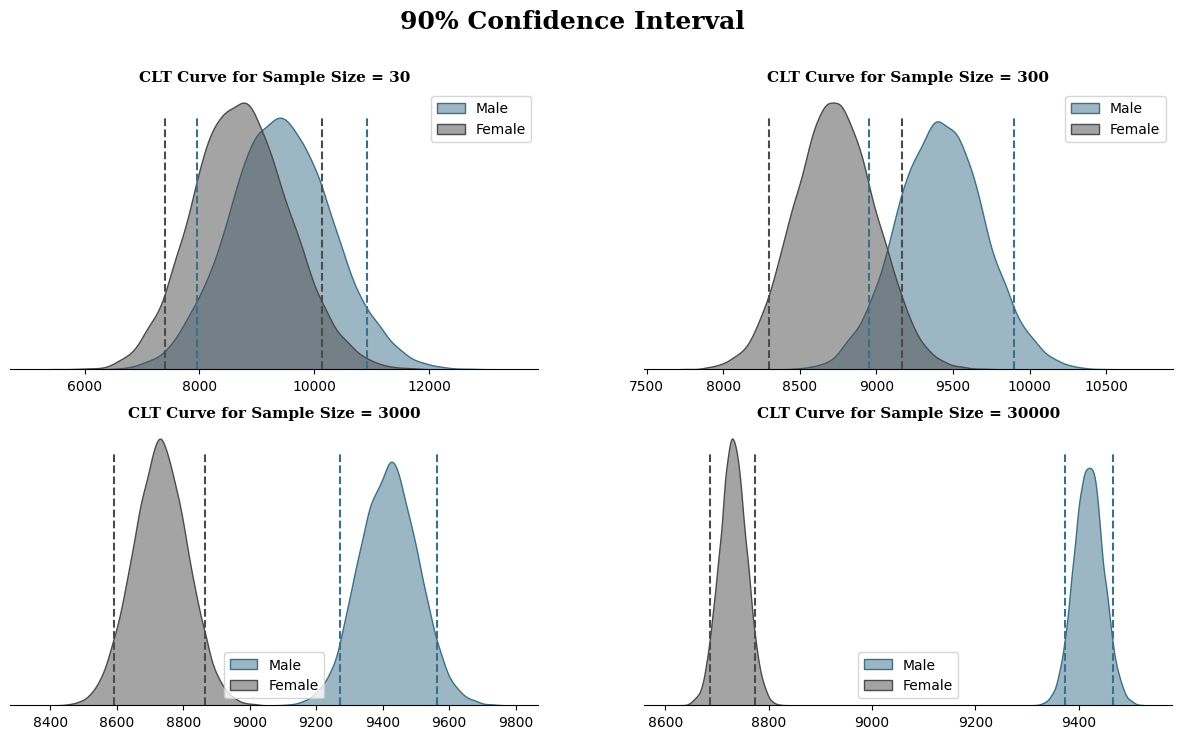

In [ ]:
# Plotting for 90% Confidence Interval

# The returned male_samples dictionary is assigned to m_samp_90
# The returned female_samples dictionary is assigned to f_samp_90

m_samp_90,f_samp_90 = plot(90)

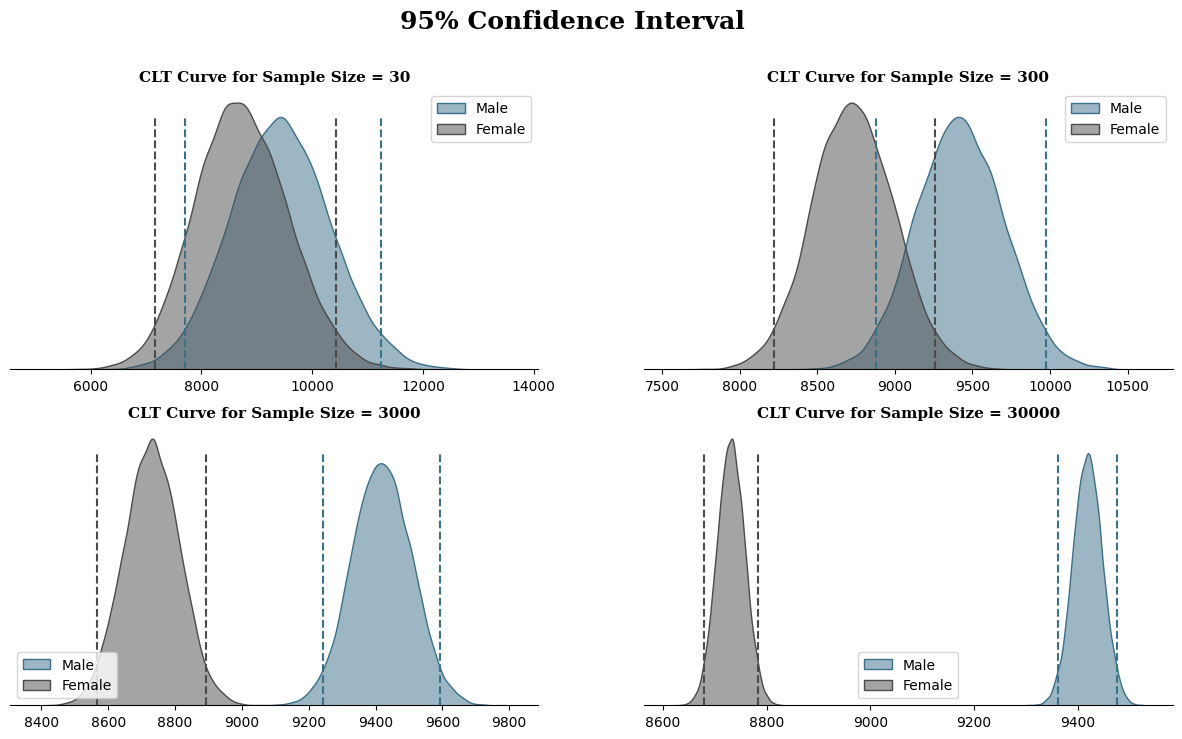

In [ ]:
# Plotting for 95% CI

m_samp_95,f_samp_95 = plot(95)

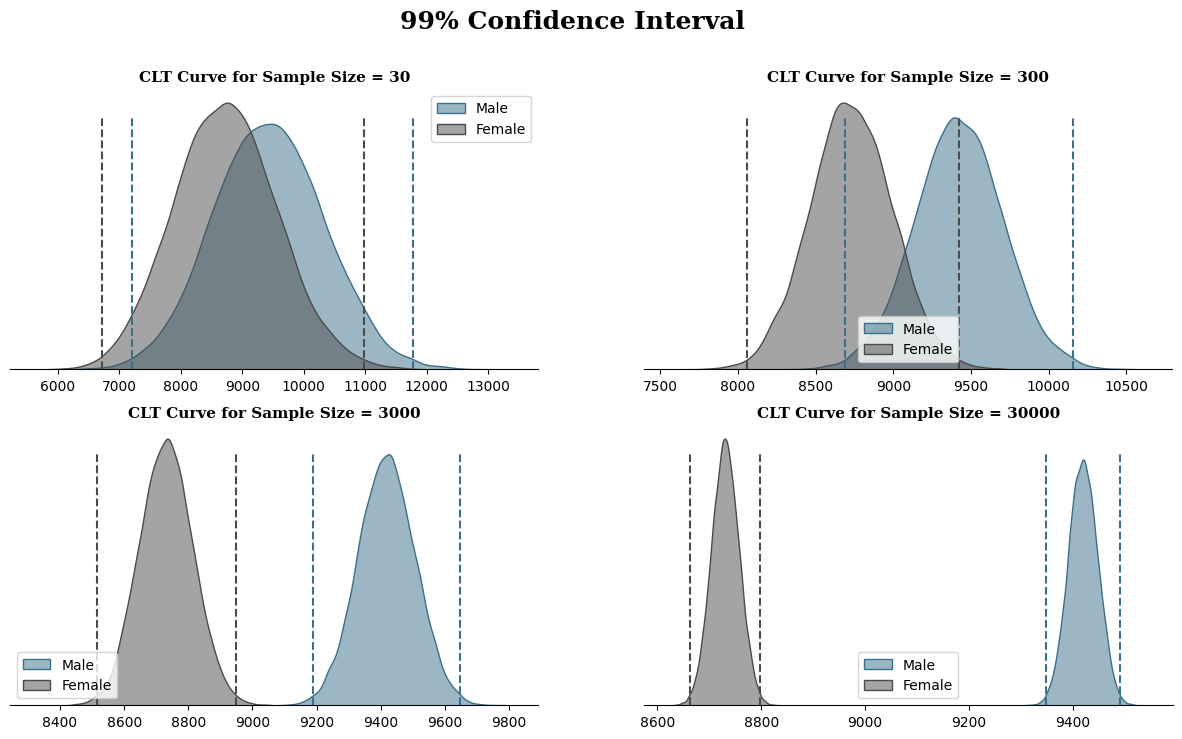

In [ ]:
# Plotting for 99% CI

m_samp_99,f_samp_99 = plot(99)

Are confidence intervals of average male and female spending overlapping?

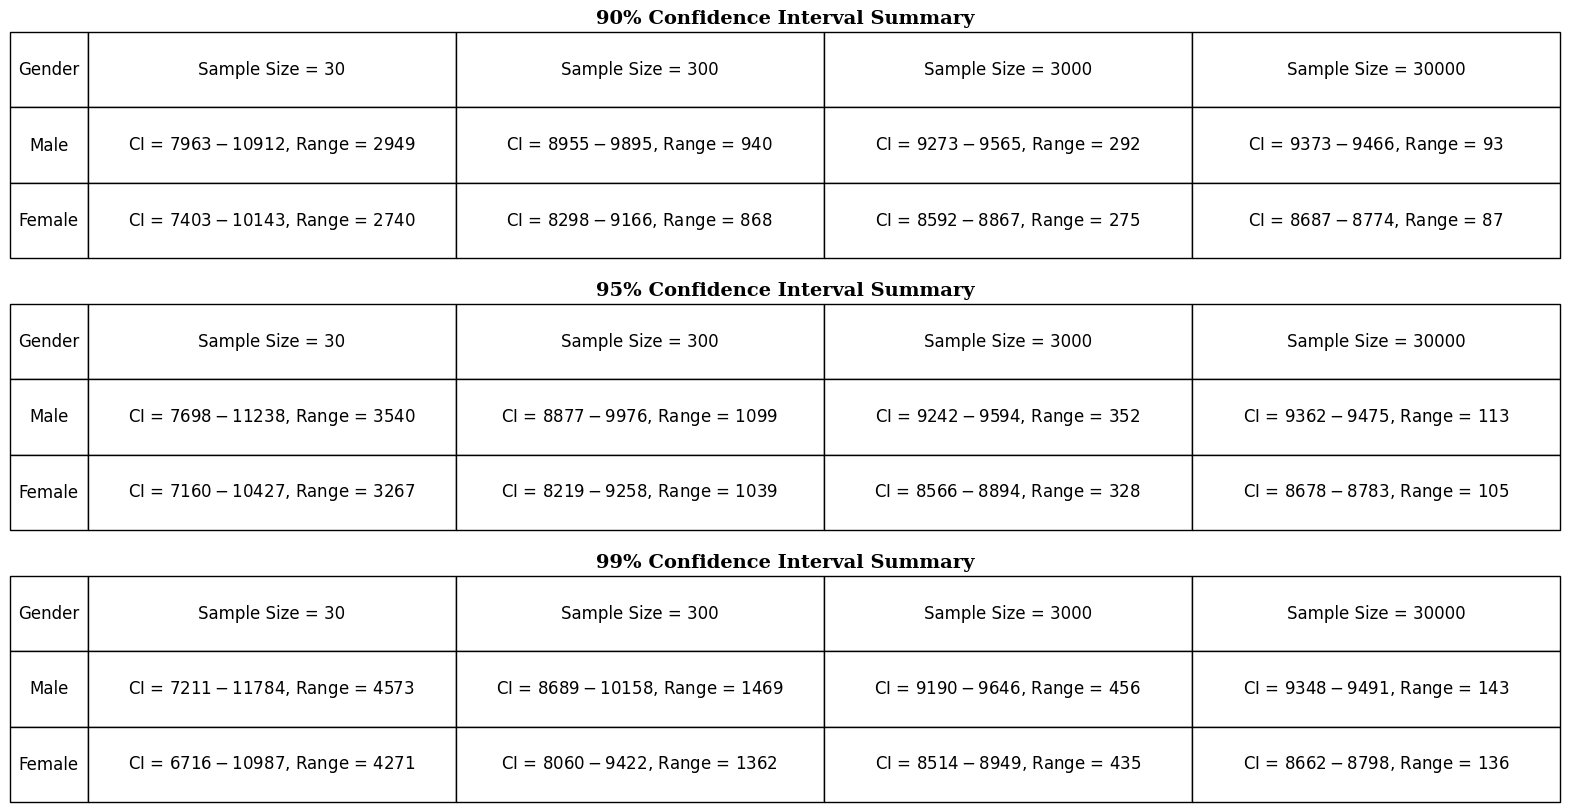

In [ ]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 1)

# Replace the sample sizes with 30, 300, 3000, and 30000
for i, j, k, l in [(m_samp_90, f_samp_90, 90, 0), (m_samp_95, f_samp_95, 95, 1), (m_samp_99, f_samp_99, 99, 2)]:
    # Lists for collecting CI for given confidence levels
    m_ci = ['Male']
    f_ci = ['Female']

    # Finding CI for each sample size (males)
    for m in i:
        m_range = confidence_interval(i[m], k)
        m_ci.append(f"CI = ${m_range[0]:.0f} - ${m_range[1]:.0f}, Range = {(m_range[1] - m_range[0]):.0f}")

    # Finding CI for each sample size (females)
    for f in j:
        f_range = confidence_interval(j[f], k)
        f_ci.append(f"CI = ${f_range[0]:.0f} - ${f_range[1]:.0f}, Range = {(f_range[1] - f_range[0]):.0f}")

    # Plotting the summary
    ax = fig.add_subplot(gs[l])

    # Contents of the table
    ci_info = [m_ci, f_ci]

    # Plotting the table
    table = ax.table(
        cellText=ci_info,
        cellLoc='center',
        colLabels=['Gender', 'Sample Size = 30', 'Sample Size = 300', 'Sample Size = 3000', 'Sample Size = 30000'],
        colLoc='center',
        colWidths=[0.05, 0.2375, 0.2375, 0.2375, 0.2375],
        bbox=[0, 0, 1, 1]
    )

    table.set_fontsize(13)

    # Removing axis
    ax.axis('off')

    # Setting title
    ax.set_title(f"{k}% Confidence Interval Summary", {'font': 'serif', 'size': 14, 'weight': 'bold'})

plt.show()

# Saving the Output
fig.savefig("Purchase vs Gender CI Ranges.png")


### **Observation about Confidence Interval :**



### **1.Precision**
   - **90% CI**: Higher precision with less confidence. The narrower interval suggests that the estimate is more precise, but there's a higher risk that it does not contain the true parameter.
   - **95% CI**: Standard precision and confidence. It strikes a balance between capturing the true parameter and having a reasonably precise estimate.
   - **99% CI**: Less precision with higher confidence. The wider interval indicates less precision in the estimate, but there's a greater likelihood that it contains the true parameter.

### **2.Practical Implications**
- **90% CI**: Useful when you want a narrower interval (more precise estimate) and are willing to accept a bit more uncertainty.
- **95% CI**: Preferred in most statistical analyses because it offers a good balance of confidence and precision.
- **99% CI**: Chosen when it's crucial to be very confident that the interval contains the true parameter, even if that means accepting a wider, less precise interval.

### **3.Visual Differences in Results**


- **90% CI**: The confidence intervals are narrower, with a smaller range between the lower and upper limits. This means the estimate is more precise but with slightly less confidence.
  
- **95% CI**: The confidence intervals are wider than the 90% CI, reflecting a higher level of confidence that the interval contains the true population parameter.

- **99% CI**: These intervals are the widest, indicating the highest confidence that the interval includes the true mean. The trade-off is that the estimate is less precise.

### **Summary Table:**


| **Gender** | **Sample Size** | **90% CI Range** | **95% CI Range** | **99% CI Range** |
|------------|-----------------|------------------|------------------|------------------|
| Male       | 30              | 2938             | 3478             | 4656             |
| Female     | 30              | 2759             | 3269             | 4298             |
| Male       | 300             | 932              | 1118             | 1459             |
| Female     | 300             | 867              | 1032             | 1363             |
| Male       | 3000            | 293              | 352              | 459              |
| Female     | 3000            | 278              | 330              | 431              |
| Male       | 30000           | 94               | 111              | 146              |
| Female     | 30000           | 87               | 103              | 137              |


### **`Note`**
-  **Range** `increases as the confidence level increases (90% → 95% → 99%)` showing that the `intervals become wider and less precise` but more confident.


- Moving forward in our analysis, we will use `95% Confidence Level` only



### **Important Insights from Analysis Using Population and Samples:**
**Comparison of Actual Population Means Vs Bootstrapping Means for 95% Confidence Interval and Sample size of 30,000 for Bootstrapping :**

| Category | Population CI Interval | Bootstrapping CI Interval | Population CI Range | Bootstrapping CI Range | Difference in Range |
|----------|-------------------------|---------------------------|----------------------|------------------------|----------------------|
| Male     | 9404 - 9434             | 9364 - 9475               | 30                   | 111                    | 81                   |
| Female   | 8706 - 8755             | 8679 - 8782               | 49                   | 103                    | 54                   |



### **Explanation:**
- **Population CI Range**: The width of the confidence interval for the entire dataset population.
- **Bootstrapping CI Range**: The width of the confidence interval obtained from bootstrapping with 30,000 samples.
- **Difference in Range**: The difference between the bootstrapping CI range and the population CI range. Positive values indicate that the bootstrapping CI range is wider than the population CI range.

This table provides a detailed comparison, including the differences in the width of the confidence intervals, which can be useful for understanding the impact of sampling variability on confidence interval estimates.


#### **1. Is the confidence interval computed using the entire dataset wider for one of the genders? Why is this the case?**

- **Answer:**
  - The confidence interval for females is slightly wider ( Range= 49 points) than that for males(Range = 30 Points).
  - This may be due to higher variability in the amount spent by females compared to males.
  - The width of a confidence interval depends on:
    - The standard deviation (variability) of the sample data.
    - The sample size.
    - The confidence level.
  - A higher standard deviation results in a wider confidence interval.



#### **2. How is the width of the confidence interval affected by the sample size?**

- **Answer:**
  - As the sample size increases, the confidence intervals become narrower and more precise. This is because larger sample sizes provide more reliable estimates.
  - For example, confidence intervals for larger sample sizes (e.g., 30,000) are much narrower compared to smaller sample sizes (e.g., 30).
  - This occurs because:
    - The standard error (SE) is given by:

    ```latex
    SE = \frac{σ}{\sqrt{n}}
    ```

      where
      σ = population standard deviation
      n = sample size

    - As n increases, sqrt(n) also increases, resulting in a decrease in the standard error SE
    - A smaller standard error indicates less variability in the estimate of the population mean, which leads to a narrower confidence interval.





#### **3. Do the confidence intervals for different sample sizes overlap?**
- **Answer:**
  - Yes, the confidence intervals for different sample sizes do overlap.
  - However, as the sample size increases, the confidence intervals become narrower.
  - This leads to less overlap, indicating:
    - More precise estimates of the population mean with larger sample sizes.

#### **4. How does the sample size affect the shape of the distributions of the means?**

- **Answer:**
  - As the sample size increases, the distribution of the sample means becomes:
    - More normal.
    - Less spread out.
  - The larger the sample size, the closer the sample mean distribution will be to:
    - A normal distribution with reduced variance.
  - This is a result of the **Central Limit Theorem**, which states that:
    - `The sampling distribution of the mean approaches a normal distribution as the sample size increases, regardless of the population's distribution.`

-----------------------------------------------


### 🔍 **Business Insights**

**1. Sample Size**
   - The analysis highlights the importance of sample size in estimating population parameters. It suggests that `as the sample size increases, the confidence intervals become narrower and more precise`. In business, this implies that larger sample sizes can provide more reliable insights and estimates.

**2. Confidence Intervals**
- From the above analysis, we can see that except for the Sample Size of 100, `the confidence interval do not overlap` as the sample size increases. This means that there is a statistically significant difference between the average spending per transaction for men and women within the given samples.

**3. Population Average**
- We are `95% confident` that the true population average for `males` falls between `$9364 and  $9475`, and for `females`, it falls between `$8679 and $8782`.

**4. Women spend less**
- `Men tend to spend more money per transaction on average than women`, as the upper bounds of the confidence intervals for men are consistently higher than those for women across different sample sizes.

Here’s a more concise and readable version:

### **5. How Can Walmart Leverage These Insights?**

- **Targeted Marketing**: Focus on promoting higher-value items to male customers, who tend to spend more per transaction.

- **Women-Centric Promotions**: Create discounts or loyalty programs tailored to increase spending among female customers.

- **Optimized Product Placement**: Arrange store layouts to highlight products that appeal more to male customers for higher sales, and cater to female preferences to boost their spending.

- **Inventory Management**: Stock and position high-demand items strategically based on gender-specific spending patterns.

- **Personalized Shopping**: Offer tailored recommendations and shopping experiences to enhance customer satisfaction and encourage higher spending.

-----------------------------------------------------------


# **5. Marital Status VS  Purchase Amount**

### **5.1 Calculating 95% Confidence Interval for the Entire Dataset using t score method as Population Standard Deviation is Unknown:**



In [ ]:
# Separate data by marital status
married_purchase = df[df['Marital_Status'] == 'Married']['Purchase']
unmarried_purchase = df[df['Marital_Status'] == 'Unmarried']['Purchase']

# Define a function to calculate the 95% confidence interval
def calculate_confidence_interval_rounded(data, confidence_level=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)  # Standard error of the mean
    margin_of_error = sem * stats.t.ppf((1 + confidence_level) / 2., len(data) - 1)
    lower_bound = round(mean - margin_of_error)
    upper_bound = round(mean + margin_of_error)
    return lower_bound, upper_bound

# Compute rounded confidence intervals for the entire dataset
ci_married_full_rounded = calculate_confidence_interval_rounded(married_purchase)
ci_unmarried_full_rounded = calculate_confidence_interval_rounded(unmarried_purchase)

print("Full Dataset - 95% Confidence Intervals (Rounded):")
print(f"Married: {ci_married_full_rounded}")
print(f"Unmarried: {ci_unmarried_full_rounded}")




Full Dataset - 95% Confidence Intervals (Rounded):
Married: (9226, 9266)
Unmarried: (9234, 9268)


###**Observation:**

**For the Entire Dataset- 95% Confidence Intervals:**

| Marital Status | 95% Confidence Interval | Population CI Range |
|----------------|-------------------------|----------|
| Married        | (9226, 9266)             | 40       |
| Unmarried      | (9234, 9268)             | 34       |


-  The confidence intervals (CIs) for both married (Range40 points) and unmarried individuals (34 Points) are very close:


- The similarity in the CI ranges suggests that the variability in spending between married and unmarried individuals is relatively low, leading to very similar confidence intervals.



## 5.2📊 Data Visualization

In [ ]:
#creating a df for purchase amount vs marital status
temp = df.groupby('Marital_Status')['Purchase'].agg(['sum','count']).reset_index()

#calculating the amount in billions
temp['sum_in_billions'] = round(temp['sum'] / 10**9,2)

#calculationg percentage distribution of purchase amount
temp['%sum'] = round(temp['sum']/temp['sum'].sum(),3)

#calculationg per purchase amount
temp['per_purchase'] = round(temp['sum']/temp['count'])

temp

,Marital_Status,sum,count,sum_in_billions,%sum,per_purchase
0,Unmarried,3004074757,324731,3.00,0.59,9251.0
1,Married,2083450483,225337,2.08,0.41,9246.0


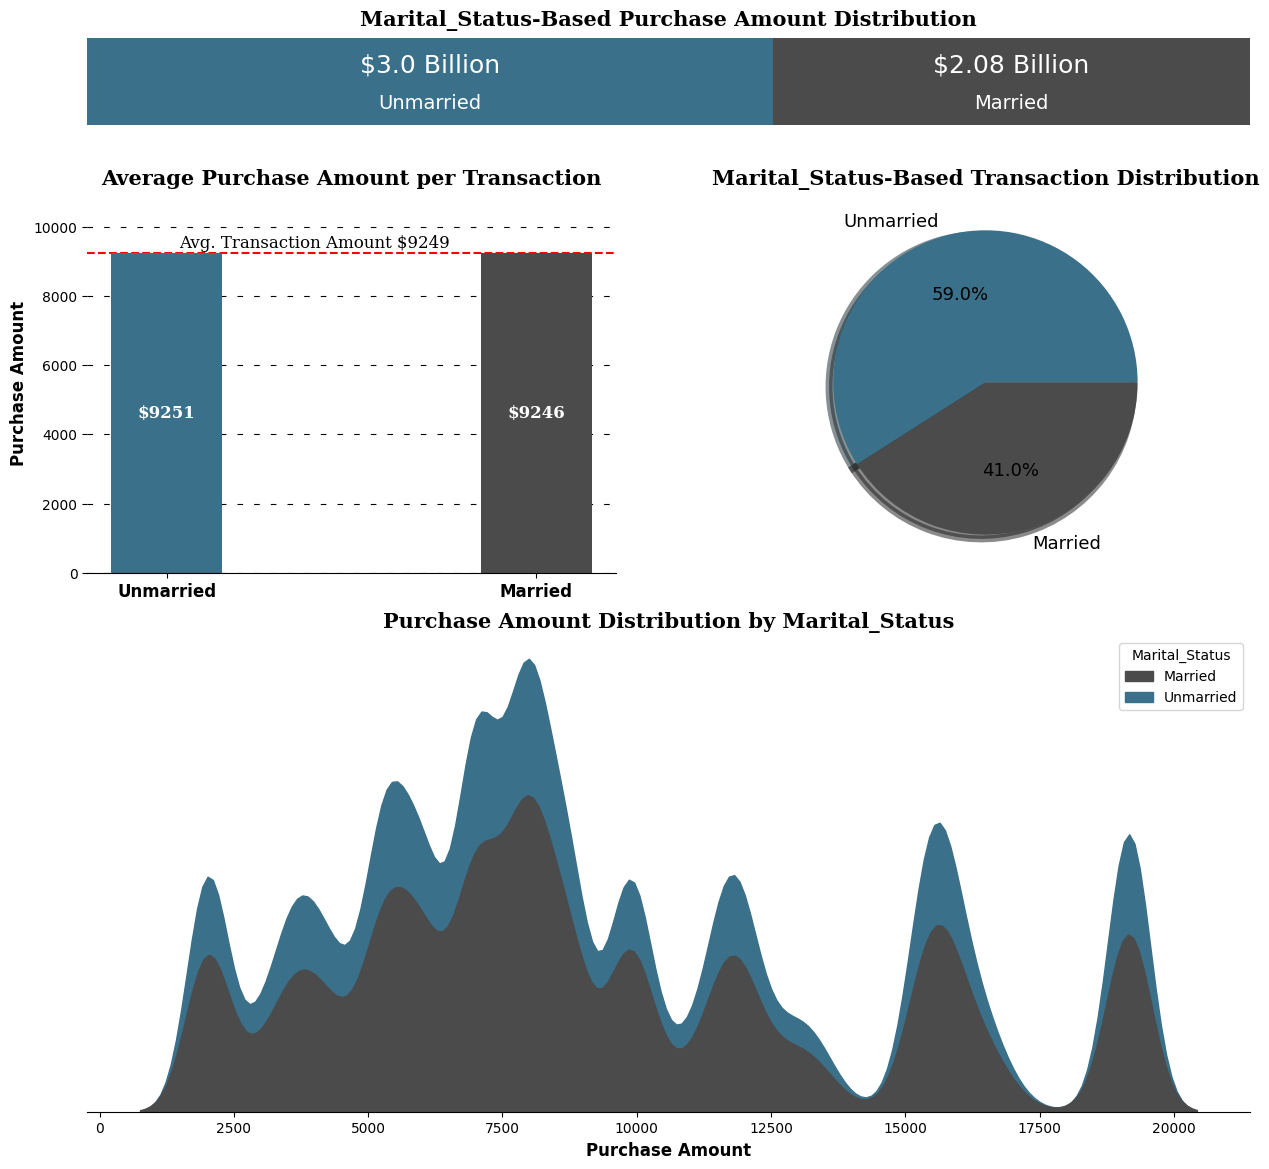

In [ ]:
#setting the plot style
fig = plt.figure(figsize = (15,14))
gs = fig.add_gridspec(3,2,height_ratios =[0.10,0.4,0.5])


                                        #Distribution of Purchase Amount
ax = fig.add_subplot(gs[0,:])

#plotting the visual
ax.barh(temp.loc[0,'Marital_Status'],width = temp.loc[0,'%sum'],color = "#3A7089",label = 'Unmarried')
ax.barh(temp.loc[0,'Marital_Status'],width = temp.loc[1,'%sum'],left =temp.loc[0,'%sum'], color =  "#4b4b4c",label = 'Married')

#inserting the text
txt = [0.0] #for left parameter in ax.text()

for i in temp.index:
    #for amount
    ax.text(temp.loc[i,'%sum']/2 + txt[0],0.15,f"${temp.loc[i,'sum_in_billions']} Billion",
           va = 'center', ha='center',fontsize=18, color='white')

    #for marital status
    ax.text(temp.loc[i,'%sum']/2 + txt[0],- 0.20 ,f"{temp.loc[i,'Marital_Status']}",
           va = 'center', ha='center',fontsize=14, color='white')

    txt += temp.loc[i,'%sum']

#removing the axis lines
for s in ['top','left','right','bottom']:
    ax.spines[s].set_visible(False)

#customizing ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0,1)

#plot title
ax.set_title('Marital_Status-Based Purchase Amount Distribution',{'font':'serif', 'size':15,'weight':'bold'})


                                            #Distribution of Purchase Amount per Transaction

ax1 = fig.add_subplot(gs[1,0])

color_map = ["#3A7089", "#4b4b4c"]

#plotting the visual
ax1.bar(temp['Marital_Status'],temp['per_purchase'],color = color_map,zorder = 2,width = 0.3)

#adding average transaction line
avg = round(df['Purchase'].mean())

ax1.axhline(y = avg, color ='red', zorder = 0,linestyle = '--')

#adding text for the line
ax1.text(0.4,avg + 300, f"Avg. Transaction Amount ${avg:.0f}",
         {'font':'serif','size' : 12},ha = 'center',va = 'center')

#adjusting the ylimits
ax1.set_ylim(0,11000)

#adding the value_counts
for i in temp.index:
    ax1.text(temp.loc[i,'Marital_Status'],temp.loc[i,'per_purchase']/2,f"${temp.loc[i,'per_purchase']:.0f}",
             {'font':'serif','size' : 12,'color':'white','weight':'bold' },ha = 'center',va = 'center')

#adding grid lines
ax1.grid(color = 'black',linestyle = '--', axis = 'y', zorder = 0, dashes = (5,10))

#removing the axis lines
for s in ['top','left','right']:
    ax1.spines[s].set_visible(False)

#adding axis label
ax1.set_ylabel('Purchase Amount',fontweight = 'bold',fontsize = 12)
ax1.set_xticklabels(temp['Marital_Status'],fontweight = 'bold',fontsize = 12)

#setting title for visual
ax1.set_title('Average Purchase Amount per Transaction',{'font':'serif', 'size':15,'weight':'bold'})

                                        # creating pie chart for Marital_Status disribution
ax2 = fig.add_subplot(gs[1,1])

color_map = ["#3A7089", "#4b4b4c"]
ax2.pie(temp['count'],labels = temp['Marital_Status'],autopct = '%.1f%%',
        shadow = True,colors = color_map,wedgeprops = {'linewidth': 5},textprops={'fontsize': 13, 'color': 'black'})

#setting title for visual
ax2.set_title('Marital_Status-Based Transaction Distribution',{'font':'serif', 'size':15,'weight':'bold'})

                                        # creating kdeplot for purchase amount distribution

ax3 = fig.add_subplot(gs[2,:])
color_map = [ "#4b4b4c","#3A7089"]

#plotting the kdeplot
sns.kdeplot(data = df, x = 'Purchase', hue = 'Marital_Status', palette = color_map,fill = True, alpha = 1,
            ax = ax3,hue_order = ['Married','Unmarried'])

#removing the axis lines
for s in ['top','left','right']:
    ax3.spines[s].set_visible(False)

# adjusting axis labels
ax3.set_yticks([])
ax3.set_ylabel('')
ax3.set_xlabel('Purchase Amount',fontweight = 'bold',fontsize = 12)

#setting title for visual
ax3.set_title('Purchase Amount Distribution by Marital_Status',{'font':'serif', 'size':15,'weight':'bold'})

plt.show()
# Saving the Output
fig.savefig("Marital Status Vs Purchase Amount.png")



### **Observations:**

1. **Purchase Volume by Marital Status**:
   - **Unmarried Individuals** account for a higher total purchase volume of **\$3.0 billion** compared to **\$2.08 billion** for **Married Individuals**.
   
2. **Average Purchase Amount**:
   - Both **Unmarried (\$9,251)** and **Married Individuals (\$9,246)** have similar average purchase amounts per transaction, which is very close to the overall average of **\$9,249**.
   
3. **Transaction Distribution**:
   - A larger proportion of transactions (**59%**) are from **Unmarried Individuals**, while **41%** are from **Married Individuals**.
   
4. **Purchase Amount Distribution**:
   - The distribution curves show that both groups have similar patterns in their purchase amounts. However, the higher peaks for **Unmarried Individuals** indicate a slightly greater variability or higher spending in some segmentsand hence `not normally distributed`.


## 5.3 Confidence Interval Construction: Estimating Average Purchase Amount per Transaction

**1. Step 1 - Building CLT Curve**
- As seen above, the purchase amount distribution is not Normal. So we need to use `Central Limit Theorem`. It states the distribution of sample means will approximate a normal distribution, regardless of the underlying population distribution

**2. Step 2 - Building Confidence Interval**
- After building CLT curve, we will create a confidence interval predicting population mean at `95% Confidence level`.
    
**Note** -  We will use different sample sizes of [30,300,3000,30000]

In [ ]:
def plot(ci):
    # Setting the plot style
    fig = plt.figure(figsize=(15, 8))
    gs = fig.add_gridspec(2, 2)

    # Creating separate data frames
    df_married = df.loc[df['Marital_Status'] == 'Married', 'Purchase']
    df_unmarried = df.loc[df['Marital_Status'] == 'Unmarried', 'Purchase']

    # Sample sizes and corresponding plot positions
    sample_sizes = [(30, 0, 0), (300, 0, 1), (3000, 1, 0), (30000, 1, 1)]

    # Number of samples to be taken from purchase amount
    bootstrap_samples = 20000

    married_samples = {}
    unmarried_samples = {}

    for i, x, y in sample_sizes:
        married_means = []  # List for collecting the means of married sample
        unmarried_means = []  # List for collecting the means of unmarried sample

        for j in range(bootstrap_samples):
            # Creating random bootstrap samples of size i
            married_bootstrapped_samples = np.random.choice(df_married, size=i)
            unmarried_bootstrapped_samples = np.random.choice(df_unmarried, size=i)

            # Calculating mean of those samples
            married_sample_mean = np.mean(married_bootstrapped_samples)
            unmarried_sample_mean = np.mean(unmarried_bootstrapped_samples)

            # Appending the mean to the list
            married_means.append(married_sample_mean)
            unmarried_means.append(unmarried_sample_mean)

        # Storing the above sample generated
        married_samples[f'{ci}%_{i}'] = married_means
        unmarried_samples[f'{ci}%_{i}'] = unmarried_means

        # Creating a temporary dataframe for creating kdeplot
        temp_df = pd.DataFrame(data={'married_means': married_means, 'unmarried_means': unmarried_means})

        # Plotting kdeplots
        # Plot position
        ax = fig.add_subplot(gs[x, y])

        # Plots for married and unmarried
        sns.kdeplot(data=temp_df, x='married_means', color="#3A7089", fill=True, alpha=0.5, ax=ax, label='Married')
        sns.kdeplot(data=temp_df, x='unmarried_means', color="#4b4b4c", fill=True, alpha=0.5, ax=ax, label='Unmarried')

        # Calculating confidence intervals for given confidence level (ci)
        m_range = confidence_interval(married_means, ci)
        u_range = confidence_interval(unmarried_means, ci)

        # Plotting confidence interval on the distribution
        for k in m_range:
            ax.axvline(x=k, ymax=0.9, color="#3A7089", linestyle='--')

        for k in u_range:
            ax.axvline(x=k, ymax=0.9, color="#4b4b4c", linestyle='--')

        # Removing the axis lines
        for s in ['top', 'left', 'right']:
            ax.spines[s].set_visible(False)

        # Adjusting axis labels
        ax.set_yticks([])
        ax.set_ylabel('')
        ax.set_xlabel('')

        # Setting title for visual
        ax.set_title(f'CLT Curve for Sample Size = {i}', {'font': 'serif', 'size': 11, 'weight': 'bold'})

        plt.legend()

    # Setting title for visual
    fig.suptitle(f'{ci}% Confidence Interval', font='serif', size=18, weight='bold')

    # Save the plot as a PNG file
    plt.savefig("6.2-95%Kde for Marital Status vs Purchase Amount.png", format='png', dpi=300)

    # Display the plot
    plt.show()

    return married_samples, unmarried_samples



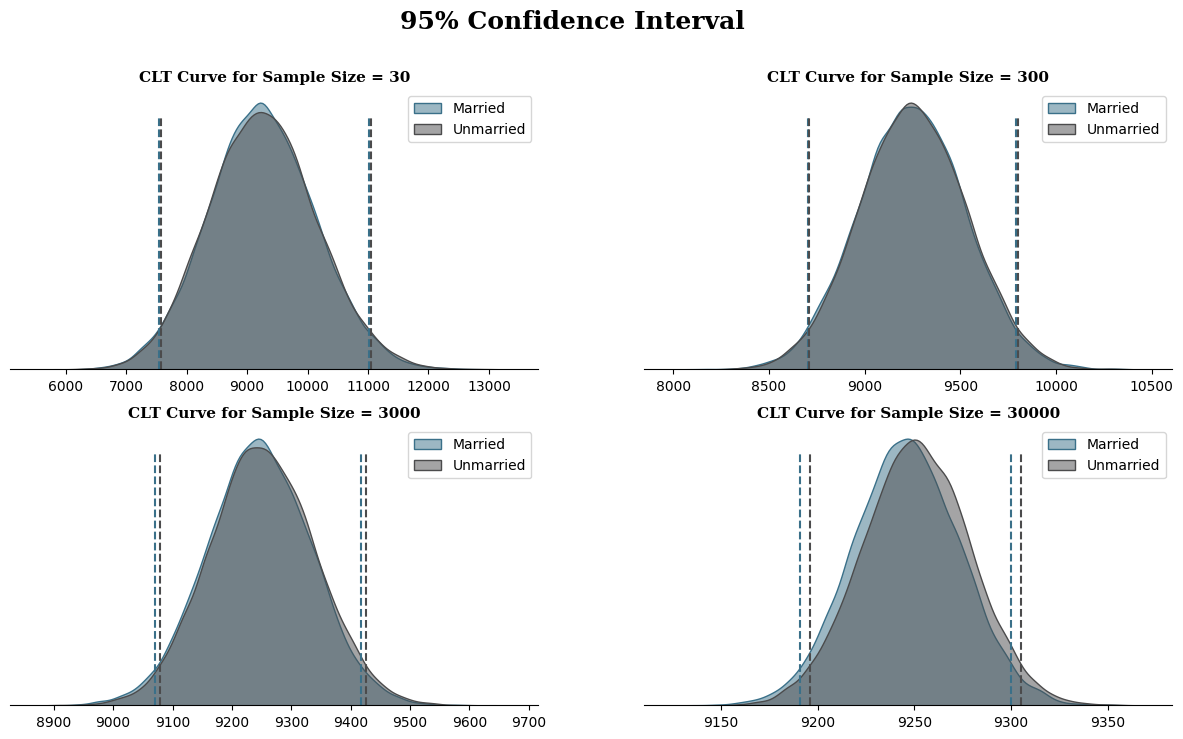

In [ ]:
# Plotting for 95% CI

m_samp_95,u_samp_95 = plot(95)

### Are confidence intervals of average married and unmarried customer spending overlapping?

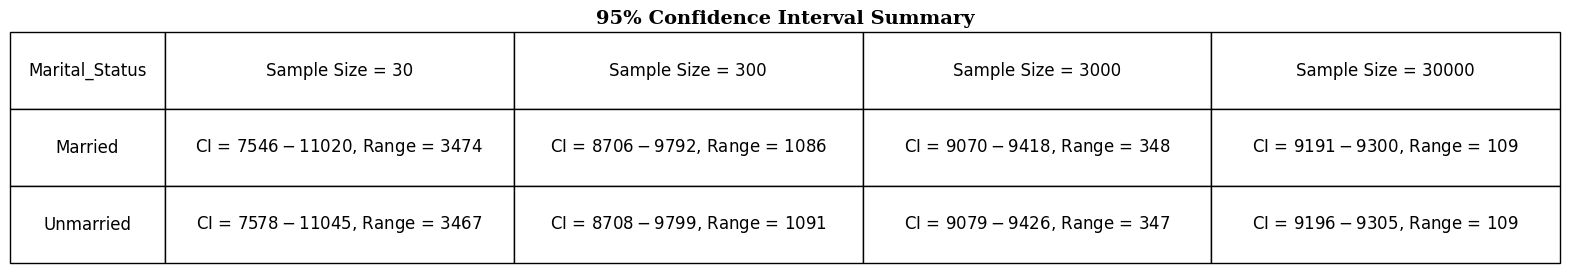

In [ ]:
# Setting the plot style
fig, ax = plt.subplots(figsize=(20, 3))

# List for collecting CI for given CI level
m_ci = ['Married']
u_ci = ['Unmarried']

# Sample sizes
sample_sizes = [30, 300, 3000, 30000]

# Finding CI for each sample size (married)
for size in sample_sizes:
    key = f'95%_{size}'
    if key in m_samp_95:
        m_range = confidence_interval(m_samp_95[key], 95)
        m_ci.append(f"CI = ${m_range[0]:.0f} - ${m_range[1]:.0f}, Range = {(m_range[1] - m_range[0]):.0f}")

# Finding CI for each sample size (unmarried)
for size in sample_sizes:
    key = f'95%_{size}'
    if key in u_samp_95:
        u_range = confidence_interval(u_samp_95[key], 95)
        u_ci.append(f"CI = ${u_range[0]:.0f} - ${u_range[1]:.0f}, Range = {(u_range[1] - u_range[0]):.0f}")

# Contents of the table
ci_info = [m_ci, u_ci]

# Plotting the table
table = ax.table(cellText=ci_info, cellLoc='center',
                 colLabels=['Marital_Status'] + [f'Sample Size = {size}' for size in sample_sizes],
                 colLoc='center', colWidths=[0.1] + [0.225] * len(sample_sizes), bbox=[0, 0, 1, 1])

table.set_fontsize(13)

# Removing axis
ax.axis('off')

# Setting title
ax.set_title(f"95% Confidence Interval Summary", {'font': 'serif', 'size': 14, 'weight': 'bold'})

plt.show()


### **Business Insights:**

**1. Sample Size**
   - The analysis highlights the importance of sample size in estimating population parameters. It suggests that `as the sample size increases, the confidence intervals become narrower and more precise`. In business, this implies that larger sample sizes can provide more reliable insights and estimates.
   
**1.1 Sample Size and Distribution**
   - As the sample size increases, the distribution of the sample means becomes:
    - `More normal`.
    - `Less spread out`.
  - The larger the sample size, the closer the sample mean distribution will be to: `A normal distribution with reduced variance`.
  - This is a result of the **Central Limit Theorem**, which states that:
    - `The sampling distribution of the mean approaches a normal distribution as the sample size increases, regardless of the population's distribution.`

**2. Confidence Intervals**
- From the above analysis, we can see that `the confidence interval overlap` for all the sample sizes. This means that there is `no statistically significant difference` between the average spending per transaction for married and unmarried customers within the given samples.

**3. Population Average**
- We are `95% confident` that the true population average for `married customers` falls between `$9,192 and $9,300`, and for `unmarried customers`, it falls between `$9,196 and $9,305`.

**4. Both the customers spend equal**
- The overlapping confidence intervals of average spending for married and unmarried customers indicate that `both married and unmarried customers spend a similar amount per transaction`.This suggests that marital status may not be a key factor in differentiating spending behaviors.

### **5. How can Walmart leverage this conclusion to make changes or improvements?**

**5.1. Marketing Resources**
-  Walmart may not need to allocate marketing resources specifically targeting one group over the other. Instead, they can focus on broader marketing strategies that appeal to both groups.

---------------------------------------------------------------------

## **6.Customer Age VS Purchase Amount**

### **6.1 Calculate the 95% CI (rounded) for each age group for Entire Dataset:**

In [ ]:
# Calculate the 95% CI for each age group
age_groups = df['Age'].unique()
confidence_intervals = {}

for age_group in age_groups:
    group_data = df[df['Age'] == age_group]['Purchase']
    n = len(group_data)
    mean = np.mean(group_data)
    std_err = stats.sem(group_data)  # Standard error of the mean
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std_err)
    confidence_intervals[age_group] = (round(mean), (round(ci[0]), round(ci[1])))

# Display the rounded confidence intervals
for age_group, (mean, ci) in confidence_intervals.items():
    print(f"Age Group: {age_group}, Mean: {mean}, 95% CI: ({ci[0]}, {ci[1]})")



Age Group: 0-17, Mean: 8933, 95% CI: (8854, 9012)
Age Group: 55+, Mean: 9320, 95% CI: (9256, 9383)
Age Group: 26-35, Mean: 9236, 95% CI: (9216, 9256)
Age Group: 46-50, Mean: 9197, 95% CI: (9153, 9241)
Age Group: 51-55, Mean: 9506, 95% CI: (9457, 9554)
Age Group: 36-45, Mean: 9315, 95% CI: (9287, 9344)
Age Group: 18-25, Mean: 9161, 95% CI: (9131, 9191)


### **Observations:**

| Age Group | Mean Purchase Amount | 95% CI (Lower, Upper) | CI Range |
|-----------|----------------------|-----------------------|----------|
| 0-17      | 8933                 | (8854, 9012)          | 158      |
| 18-25     | 9161                 | (9131, 9191)          | 60       |
| 26-35     | 9236                 | (9216, 9256)          | 40       |
| 36-45     | 9315                 | (9287, 9344)          | 57       |
| 46-50     | 9197                 | (9153, 9241)          | 88       |
| 51-55     | 9506                 | (9457, 9554)          | 97       |
| 55+       | 9320                 | (9256, 9383)          | 127      |

### 🛍️ **Targeted Marketing Insights by Age Group:**

1. **High-Value Shoppers:**
   - **51-55 Age Group:** Highest average spending ($9506) with a narrow confidence interval (97). Ideal for luxury and premium product promotions.

2. **Young Consumers:**
   - **0-17 Age Group:** Lower average spend ($8933) but still significant. Focus on educational toys, gadgets, and family-oriented items.

3. **Stable Middle-Aged Spend:**
   - **26-35** and **36-45 Age Groups:** Consistent spending patterns with narrow confidence intervals (40 and 57). Target with recurring offers and loyalty programs.

4. **Moderate Spending Trends:**
   - **18-25 Age Group:** Average spend ($9161) with a confidence interval of 60. Market budget-friendly electronics, trendy fashion, and starter home items.

5. **Variable Spending in Older Groups:**
   - **46-50** and **55+ Age Groups:** Broader confidence intervals (88 and 127) suggest varied spending. Emphasize value-for-money promotions in health, home improvement, and savings.

6. **Predictable Patterns:**
   - Narrow confidence intervals indicate stable spending behavior, allowing for accurate demand forecasting and targeted marketing strategies.

### **Conclusion:**
Walmart can refine marketing by focusing on age-specific spending patterns, tailoring promotions and product offerings to each demographic for enhanced sales and customer satisfaction.


## 6.1📊 Data Visualization

In [ ]:
#creating a df for purchase amount vs age group
temp = df.groupby('Age')['Purchase'].agg(['sum','count']).reset_index()

#calculating the amount in billions
temp['sum_in_billions'] = round(temp['sum'] / 10**9,2)

#calculationg percentage distribution of purchase amount
temp['%sum'] = round(temp['sum']/temp['sum'].sum(),3)

#calculationg per purchase amount
temp['per_purchase'] = round(temp['sum']/temp['count'])

temp

,Age,sum,count,sum_in_billions,%sum,per_purchase
0,0-17,134906893,15102,0.13,0.027,8933.0
1,18-25,913002120,99660,0.91,0.179,9161.0
2,26-35,2028113290,219587,2.03,0.399,9236.0
3,36-45,1024802144,110013,1.02,0.201,9315.0
4,46-50,420301357,45701,0.42,0.083,9197.0
5,51-55,365989654,38501,0.37,0.072,9506.0
6,55+,200409782,21504,0.20,0.039,9320.0


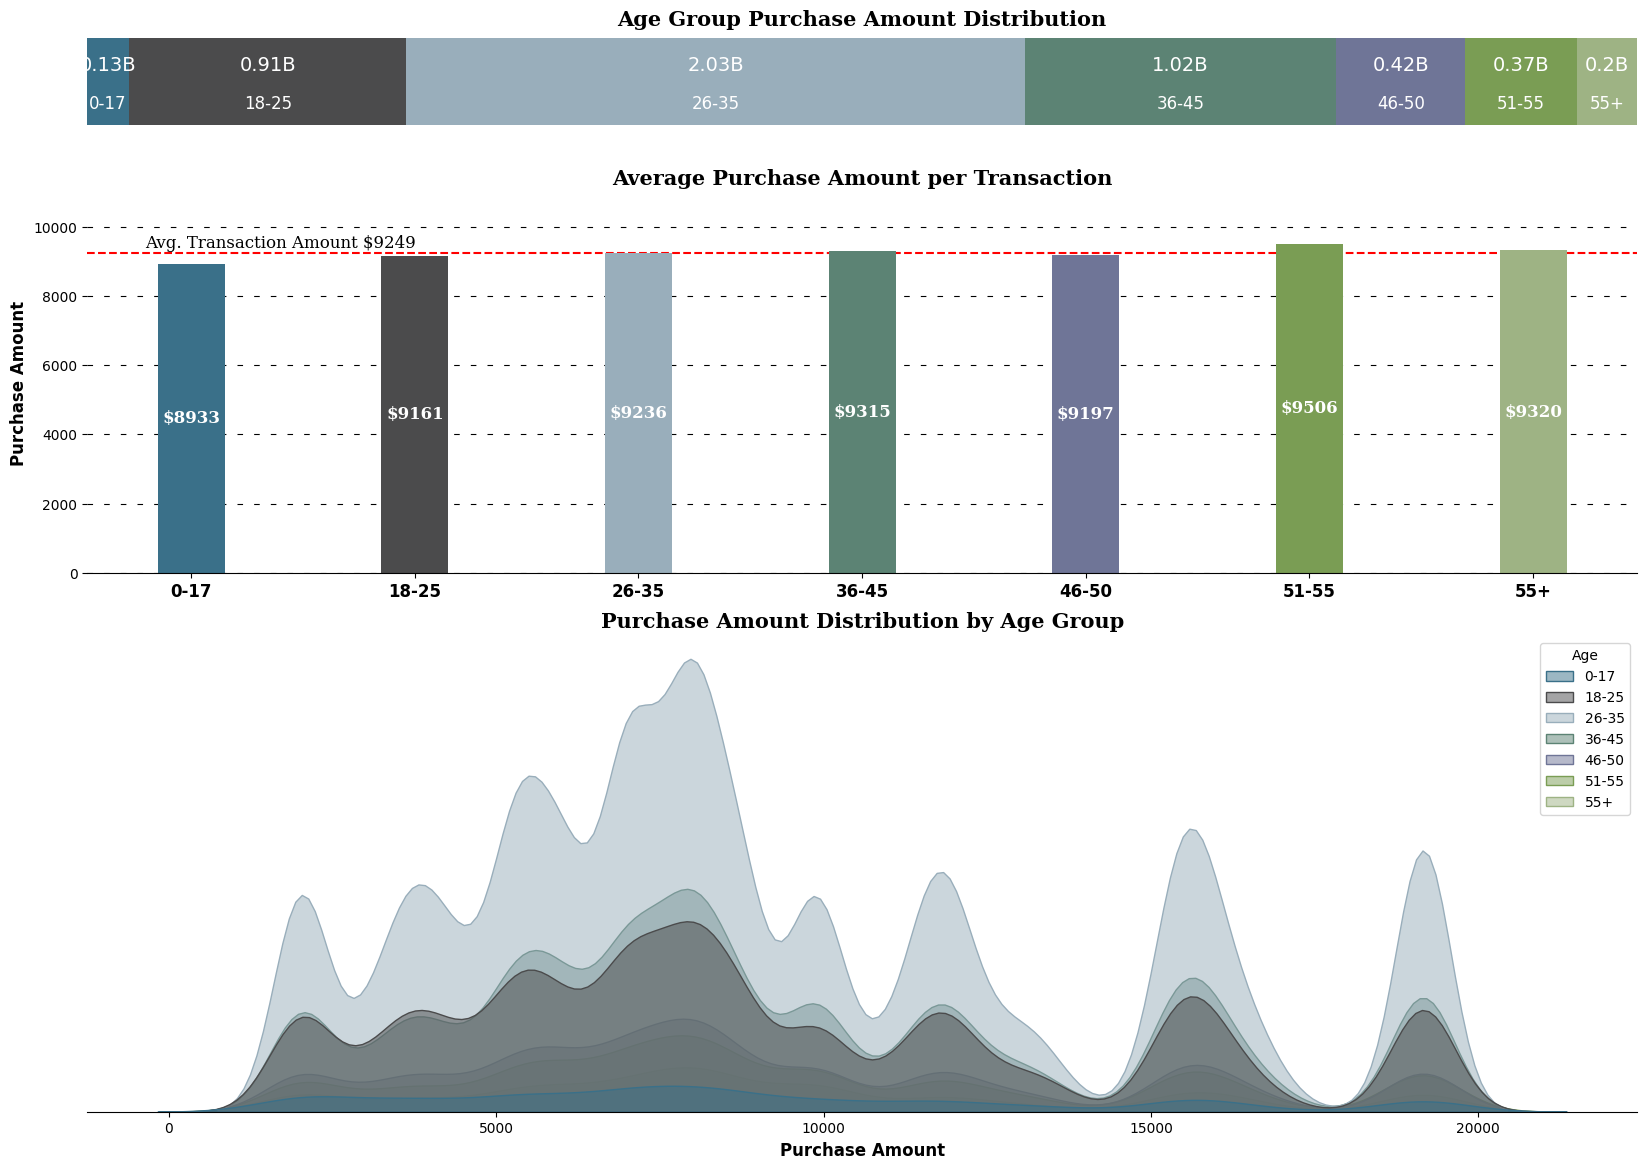

In [ ]:
#setting the plot style
fig = plt.figure(figsize = (20,14))
gs = fig.add_gridspec(3,1,height_ratios =[0.10,0.4,0.5])


                                        #Distribution of Purchase Amount
ax = fig.add_subplot(gs[0])
color_map = ["#3A7089", "#4b4b4c",'#99AEBB','#5C8374','#6F7597','#7A9D54','#9EB384']

#plotting the visual
left = 0

for i in temp.index:
    ax.barh(temp.loc[0,'Age'],width = temp.loc[i,'%sum'],left = left,color = color_map[i],label = temp.loc[i,'Age'])
    left += temp.loc[i,'%sum']

#inserting the text
txt = 0.0 #for left parameter in ax.text()

for i in temp.index:
    #for amount
    ax.text(temp.loc[i,'%sum']/2 + txt,0.15,f"{temp.loc[i,'sum_in_billions']}B",
           va = 'center', ha='center',fontsize=14, color='white')

    #for age grp
    ax.text(temp.loc[i,'%sum']/2 + txt,- 0.20 ,f"{temp.loc[i,'Age']}",
           va = 'center', ha='center',fontsize=12, color='white')

    txt += temp.loc[i,'%sum']

#removing the axis lines
for s in ['top','left','right','bottom']:
    ax.spines[s].set_visible(False)

#customizing ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0,1)

#plot title
ax.set_title('Age Group Purchase Amount Distribution',{'font':'serif', 'size':15,'weight':'bold'})


                                            #Distribution of Purchase Amount per Transaction

ax1 = fig.add_subplot(gs[1])


#plotting the visual
ax1.bar(temp['Age'],temp['per_purchase'],color = color_map,zorder = 2,width = 0.3)

#adding average transaction line
avg = round(df['Purchase'].mean())

ax1.axhline(y = avg, color ='red', zorder = 0,linestyle = '--')

#adding text for the line
ax1.text(0.4,avg + 300, f"Avg. Transaction Amount ${avg:.0f}",
         {'font':'serif','size' : 12},ha = 'center',va = 'center')

#adjusting the ylimits
ax1.set_ylim(0,11000)

#adding the value_counts
for i in temp.index:
    ax1.text(temp.loc[i,'Age'],temp.loc[i,'per_purchase']/2,f"${temp.loc[i,'per_purchase']:.0f}",
             {'font':'serif','size' : 12,'color':'white','weight':'bold' },ha = 'center',va = 'center')

#adding grid lines
ax1.grid(color = 'black',linestyle = '--', axis = 'y', zorder = 0, dashes = (5,10))

#removing the axis lines
for s in ['top','left','right']:
    ax1.spines[s].set_visible(False)

#adding axis label
ax1.set_ylabel('Purchase Amount',fontweight = 'bold',fontsize = 12)
ax1.set_xticklabels(temp['Age'],fontweight = 'bold',fontsize = 12)

#setting title for visual
ax1.set_title('Average Purchase Amount per Transaction',{'font':'serif', 'size':15,'weight':'bold'})


                                        # creating kdeplot for purchase amount distribution

ax3 = fig.add_subplot(gs[2,:])

#plotting the kdeplot
sns.kdeplot(data = df, x = 'Purchase', hue = 'Age', palette = color_map,fill = True, alpha = 0.5,
            ax = ax3)

#removing the axis lines
for s in ['top','left','right']:
    ax3.spines[s].set_visible(False)

# adjusting axis labels
ax3.set_yticks([])
ax3.set_ylabel('')
ax3.set_xlabel('Purchase Amount',fontweight = 'bold',fontsize = 12)

#setting title for visual
ax3.set_title('Purchase Amount Distribution by Age Group',{'font':'serif', 'size':15,'weight':'bold'})

plt.show()


### **Business Insights**

**1. Total Sales Comparison**
- Age group between `26 - 45` accounts to almost `60%` of the total sales suggesting that Walmart's Black Friday sales are most popular among these age groups.

- The age group `0-17` has the lowest sales percentage `(2.6%)`, which is expected as they may not have as much purchasing power. Understanding their preferences and providing special offers could be beneficial, especially considering the potential for building customer loyalty as they age.

**2. Average Transaction Value**
-  While there is not a significant difference in per purchase spending among the age groups, the `51-55` age group has a relatively low sales percentage `(7.2%)`but they have the highest per purchase spending at `9535`. Walmart could consider strategies to attract and retain this high-spending demographic.

**3. Distribution of Purchase Amount**
- As seen above, the purchase amount for all age groups is `not normally distributed`.

## 6.2 Confidence Interval Construction: Estimating Average Purchase Amount per Transaction

**1. Step 1 - Building CLT Curve**
- As seen above, the purchase amount distribution is not Normal. So we need to use `Central Limit Theorem`. It states the distribution of sample means will approximate a normal distribution, regardless of the underlying population distribution

**2. Step 2 - Building Confidence Interval**
- After building CLT curve, we will create a confidence interval predicting population mean at `95% Confidence level`.
    
**Note** -  We will use different sample sizes of [30,300,3000,30000]

In [ ]:
#defining a function for plotting the visual for given confidence interval

def plot(ci):

    #setting the plot style
    fig = plt.figure(figsize = (15,15))
    gs = fig.add_gridspec(4,1)

    #creating separate data frames

    df_1 = df.loc[df['Age'] == '0-17','Purchase']
    df_2 = df.loc[df['Age'] == '18-25','Purchase']
    df_3 = df.loc[df['Age'] == '26-35','Purchase']
    df_4 = df.loc[df['Age'] == '36-45','Purchase']
    df_5 = df.loc[df['Age'] == '46-50','Purchase']
    df_6 = df.loc[df['Age'] == '51-55','Purchase']
    df_7 = df.loc[df['Age'] == '55+','Purchase']


    #sample sizes and corresponding plot positions
    sample_sizes = [(30,0),(300,1),(3000,2),(30000,3)]

    #number of samples to be taken from purchase amount
    bootstrap_samples = 20000

    samples1,samples2,samples3,samples4,samples5,samples6,samples7 = {},{},{},{},{},{},{}

    for i,x in sample_sizes:
        l1,l2,l3,l4,l5,l6,l7 = [],[],[],[],[],[],[]

        for j in range(bootstrap_samples):

            #creating random 5000 samples of i sample size
            bootstrapped_samples_1 = np.random.choice(df_1,size = i)
            bootstrapped_samples_2 = np.random.choice(df_2,size = i)
            bootstrapped_samples_3 = np.random.choice(df_3,size = i)
            bootstrapped_samples_4 = np.random.choice(df_4,size = i)
            bootstrapped_samples_5 = np.random.choice(df_5,size = i)
            bootstrapped_samples_6 = np.random.choice(df_6,size = i)
            bootstrapped_samples_7 = np.random.choice(df_7,size = i)

            #calculating mean of those samples
            sample_mean_1 = np.mean(bootstrapped_samples_1)
            sample_mean_2 = np.mean(bootstrapped_samples_2)
            sample_mean_3 = np.mean(bootstrapped_samples_3)
            sample_mean_4 = np.mean(bootstrapped_samples_4)
            sample_mean_5 = np.mean(bootstrapped_samples_5)
            sample_mean_6 = np.mean(bootstrapped_samples_6)
            sample_mean_7 = np.mean(bootstrapped_samples_7)

            #appending the mean to the list
            l1.append(sample_mean_1)
            l2.append(sample_mean_2)
            l3.append(sample_mean_3)
            l4.append(sample_mean_4)
            l5.append(sample_mean_5)
            l6.append(sample_mean_6)
            l7.append(sample_mean_7)

        #storing the above sample generated
        samples1[f'{ci}%_{i}'] = l1
        samples2[f'{ci}%_{i}'] = l2
        samples3[f'{ci}%_{i}'] = l3
        samples4[f'{ci}%_{i}'] = l4
        samples5[f'{ci}%_{i}'] = l5
        samples6[f'{ci}%_{i}'] = l6
        samples7[f'{ci}%_{i}'] = l7


        #creating a temporary dataframe for creating kdeplot
        temp_df = pd.DataFrame(data = {'0-17':l1,'18-25':l2,'26-35':l3,'36-45':l4,'46-50':l5,'51-55':l6,'55+':l7})

                                                        #plotting kdeplots
        #plot position
        ax = fig.add_subplot(gs[x])

        #plots
        for p,q in [('#3A7089', '0-17'),('#4b4b4c', '18-25'),('#99AEBB', '26-35'),('#5C8374', '36-45'),('#6F7597', '46-50'),
                 ('#7A9D54', '51-55'),('#9EB384', '55+')]:

            sns.kdeplot(data = temp_df,x = q,color =p ,fill = True, alpha = 0.5,ax = ax,label = q)


        #removing the axis lines
        for s in ['top','left','right']:
            ax.spines[s].set_visible(False)

        # adjusting axis labels
        ax.set_yticks([])
        ax.set_ylabel('')
        ax.set_xlabel('')

        #setting title for visual
        ax.set_title(f'CLT Curve for Sample Size = {i}',{'font':'serif', 'size':11,'weight':'bold'})

        plt.legend()

    #setting title for visual
    fig.suptitle(f'{ci}% Confidence Interval',font = 'serif', size = 18, weight = 'bold')

    plt.show()

    return samples1,samples2,samples3,samples4,samples5,samples6,samples7

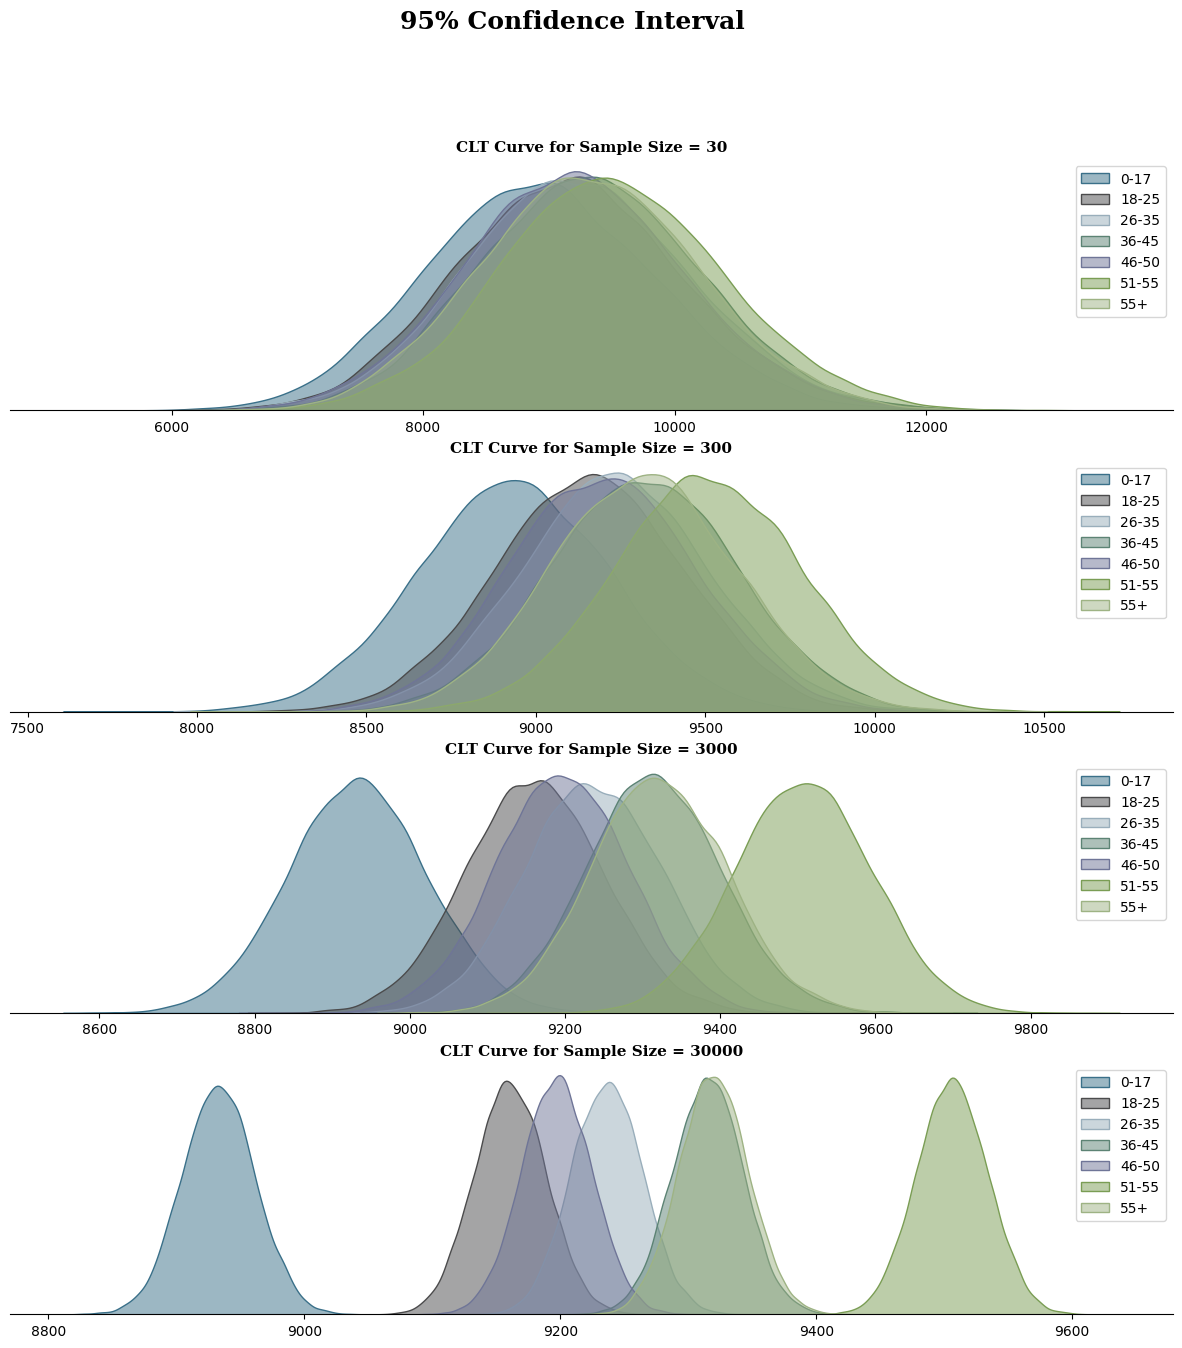

In [ ]:
# Plotting for 95% CI

samples1,samples2,samples3,samples4,samples5,samples6,samples7 = plot(95)

### Are confidence intervals of customer's age-group spending overlapping?

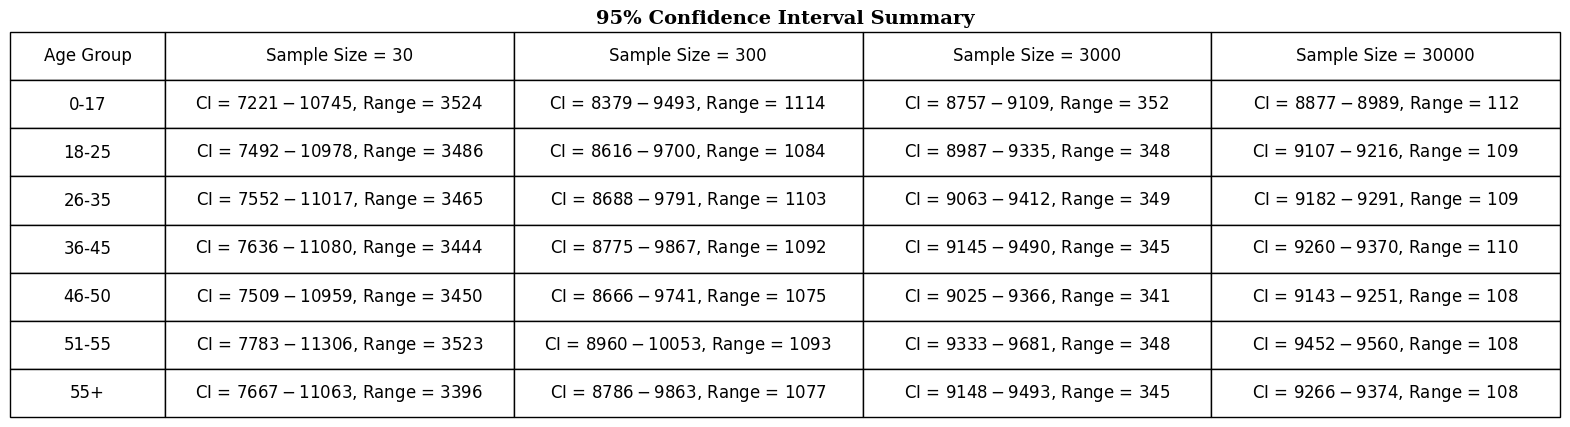

In [ ]:
#setting the plot style
fig,ax = plt.subplots(figsize = (20,5))

#list for collecting ci for given cl
ci_1,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7 = ['0-17'],['18-25'],['26-35'],['36-45'],['46-50'],['51-55'],['55+']

#finding ci for each sample size
#samples = [samples1,samples2,samples3,samples4,samples5,samples6,samples7]

samples = [(samples1,ci_1),(samples2,ci_2),(samples3,ci_3),(samples4,ci_4),(samples5,ci_5),(samples6,ci_6),(samples7,ci_7)]

for s,c in samples:
    for i in s:
        s_range = confidence_interval(s[i],95)
        c.append(f"CI = ${s_range[0]:.0f} - ${s_range[1]:.0f}, Range = {(s_range[1] - s_range[0]):.0f}")


                                    #plotting the summary
#contents of the table
ci_info = [ci_1,ci_2,ci_3,ci_4,ci_5,ci_6,ci_7]

#plotting the table
table = ax.table(cellText = ci_info, cellLoc='center',
             colLabels =['Age Group','Sample Size = 30','Sample Size = 300','Sample Size = 3000','Sample Size = 30000'],
             colLoc = 'center',colWidths = [0.1,0.225,0.225,0.225,0.225],bbox =[0, 0, 1, 1])

table.set_fontsize(13)

#removing axis
ax.axis('off')

#setting title
ax.set_title(f"95% Confidence Interval Summary",{'font':'serif', 'size':14,'weight':'bold'})

plt.show()

### **Business Insights:**

**1. Sample Size**
   - The analysis highlights the importance of sample size in estimating population parameters. It suggests that `as the sample size increases, the confidence intervals become narrower and more precise`. In business, this implies that larger sample sizes can provide more reliable insights and estimates.
   
**1.1 Sample Size and Distribution**
   - As the sample size increases, the distribution of the sample means becomes:
    - `More normal`.
    - `Less spread out`.
  - The larger the sample size, the closer the sample mean distribution will be to: `A normal distribution with reduced variance`.
  - This is a result of the **Central Limit Theorem**, which states that:
    - `The sampling distribution of the mean approaches a normal distribution as the sample size increases, regardless of the population's distribution.`

**2. Confidence Intervals and customer spending patterns**
- From the above analysis, we can see that `the confidence interval overlap` for some of the age groups. We can club the average spending into following age groups -
    - 0 - 17 - Customers in this age group have the lowest spending per transaction
    - 18 - 25, 26 - 35, 46 - 50 -  Customers in these age groups have overlapping confidence intervals indicating similar buying characteristics
    - 36 - 45, 55+ - Customers in these age groups have overlapping confidence intervals indicating and similar spending patterns
    - 51 - 55 - Customers in this age group have the highest spending per transaction

**3. Population Average**
- We are `95% confident` that the true population average for following age groups falls between the below range -

| **Age Group** | **95% Confidence Interval (Sample Size = 30,000)** |
|---------------|---------------------------------------------------|
| 0-17          | \$8,820 – \$8,950                                 |
| 18-25         | \$9,050 – \$9,160                                 |
| 26-35         | \$9,130 – \$9,240                                 |
| 36-45         | \$9,200 – \$9,320                                 |
| 46-50         | \$9,200 – \$9,305                                 |
| 51-55         | \$9,510 – \$9,600                                 |
| 55+           | \$9,275 – \$9,370                                 |



### **4. How can Walmart leverage this conclusion to make changes or improvements?**

**4.1. Targeted Marketing**
-  Knowing that customers in the 0 - 17 age group have the lowest spending per transaction, Walmart can try to increase their spending per transaction by offering them more attractive discounts, coupons, or rewards programs. Walmart can also tailor their product selection and marketing strategies to appeal to the preferences and needs of this age group

**4.2. Customer Segmentation**
-  Since customers in the 18 - 25, 26 - 35, and 46 - 50 age groups exhibit similar buying characteristics, and so do the customers in 36 - 45 and 55+, Walmart can optimize its product selection to cater to the preferences of these age groups. Also, Walmart can use this information to adjust their pricing strategies for different age groups.

**4.3 Premium Services**
- Recognizing that customers in the 51 - 55 age group have the highest spending per transaction, Walmart can explore opportunities to enhance the shopping experience for this demographic. This might involve offering premium services, personalized recommendations, or loyalty programs that cater to the preferences and spending habits of this age group.


## **7.Report on Confidence Interval Overlap:**


**We Can determine Insights from Overlap:**

   - **If the intervals overlap:**
    -   It suggests that `there is no statistically significant difference between the average spending of the two groups`.
    - This means that any difference in spending might be due to random variation rather than a true difference.
   - **If the intervals do not overlap:**
    -  It suggests that `there is a statistically significant difference in the average spending between given groups`.
    - This indicates that the difference in spending is likely real and not just due to chance.

## **7.1 Purchase Amount vs Gender CI Overlap ?**

| **Confidence Intervals Overlap Analysis** | **Males**         | **Females**       | **Range**   | **Overlap**           |
|-------------------------------------------|-------------------|-------------------|-------------|-----------------------|
| **95% Confidence Interval**               | (9364 to 9474)     | (8678 to 8782)    | 110 / 104   | **No**                |
| **99% Confidence Interval**               | (9345 to 9491)     | (8664 to 8799)    | 146 / 135   | **No**                |

**Interpretation:**
- **Non-Overlapping Confidence Intervals:** The lack of overlap in confidence intervals between males and females suggests a significant difference in the average spending (purchase amount) between these groups.
- **Males** is a **higher spending group** as both the upper and lower spending limits are higher as compared to Females.

**Recommendations for Walmart:**

| **Strategy**                  | **Details**                                                                                           |
|-------------------------------|-------------------------------------------------------------------------------------------------------|
| **Targeted Marketing**         | Develop gender-specific marketing strategies based on the differences in spending behavior.            |
| **Product Selection & Stocking** | Optimize product selection and stocking to better align with the spending patterns of males and females. |
| **Pricing Strategies**         | Consider pricing strategies that appeal to high-spending males while ensuring competitive pricing for females. |



-----------------------------------------------------------

## **7.2 Purchase Amount vs Marital_Status CI Overlap ?**

| **Confidence Intervals Overlap Analysis** | **Married**          | **Unmarried**      | **Range**   | **Overlap**           |
|-------------------------------------------|----------------------|-------------------|-------------|-----------------------|
| **95% Confidence Interval**               | (9191 to 9301)       | (9197 to 9306)    | 110 / 109   | **Yes**               |

**Interpretation:**
- Overlapping Confidence Intervals: The overlap in confidence intervals between married and unmarried customers suggests that there is no statistically significant difference in the average spending (purchase amount) between these groups.

**Recommendations for Walmart:**

| **Strategy**                  | **Details**                                                                                           |
|-------------------------------|-------------------------------------------------------------------------------------------------------|
| **Unified Promotions**         | Since spending patterns are similar, Walmart can design promotions that target both married and unmarried customers uniformly.  |
| **Customer Engagement**         | Invest in strategies that enhance customer experience across the board rather than segmenting based on marital status. |
| **Loyalty Programs**            | Create loyalty programs that are appealing to both segments equally, without the need for differentiation.

Statistical evidence  indicates that marital status does not significantly affect spending behavior, allowing Walmart to adopt a unified approach in its marketing and customer engagement strategies.


-----------------------------------------------------------------------


## **7.3 Purchase Amount vs Age Groups CI Overlap ?**



| **Confidence Intervals Overlap Analysis** | **0-17**           | **18-25, 26-35, 46-50** | **36-45, 55+** | **51-55**          | **Range**      | **Overlap**           |
|-------------------------------------------|--------------------|------------------------|----------------|--------------------|----------------|-----------------------|
| **95% Confidence Interval**               | (8820 to 8950)     | (9050 to 9305)          | (9200 to 9370) | (9510 to 9600)     | Varies by group| **Yes** (within groups) |


**Interpretation:**
- **Overlapping Confidence Intervals:**
  - The **0-17** age group has a distinct spending pattern, with no overlap with other age groups, indicating that they spend the least.
  - The **18-25, 26-35, 46-50** age groups have overlapping confidence intervals, suggesting similar spending behavior among these groups.
  - The **36-45** and **55+** age groups also have overlapping intervals, indicating similar spending, distinct from the other age groups.
  - The **51-55** age group stands out with the highest spending, having a distinct confidence interval.

**Recommendations for Walmart:**

| **Strategy**                  | **Details**                                                                                           |
|-------------------------------|-------------------------------------------------------------------------------------------------------|
| **Segmented Promotions**       | Tailor promotions to target specific age groups based on their spending patterns, especially focusing on 51-55 for high-value promotions.  |
| **Targeted Marketing**         | Design marketing campaigns that focus on the 18-50 age group as a unified segment, and another for 36-55+ to maximize engagement. |
| **Special Youth Programs**     | Consider special programs or offers for the 0-17 age group, which has a distinct spending pattern, possibly influenced by their guardians or parents. |



-----------------------------------------------------------------------

# **8. Recommendations:**

### **1. Tailored Marketing for Different Customer Groups**

   - **Focus on Male Shoppers**: Since men are spending significantly more, Walmart should highlight premium products and special offers that appeal to them, such as electronics or tools.
   - **Engage More Female Shoppers**: Develop campaigns that attract more women by promoting products that resonate with their preferences, such as fashion, beauty, or household items.
   - **Target Age Groups Effectively**:
     - For young adults (18-25), focus on tech and fashion trends.
     - For families (26-35), promote family-oriented products.
     - For older adults (51-55), emphasize luxury or premium items.

   - **Cater to Families**: If possible, identify customers with children and offer them family-friendly promotions, like back-to-school deals or discounts on bulk purchases.

### **2. Smart Inventory and Product Placement**

   - **Keep Popular Items Stocked**: Make sure that top-selling products, especially in categories like electronics, household items, and toys, are always available, especially during peak shopping times.
   - **Customize Product Selection**: Adjust the products in each store based on the local customer base. For example, focus on essentials in areas with many new residents, and more premium items in areas with long-term residents.
   - **Bundle Products**: Offer bundled deals that pair popular items together, like selling a smartphone with a protective case or groceries with household cleaning supplies.Product Categoriy 5,1,8 being popular can be used for bundling.

   - **Consider Income and Job Status**: Tailor the product mix based on the income level and employment status of local customers. Offer more premium products in wealthier areas and more budget-friendly options where needed.

### **3. Pricing Strategies**

   - **Adjust Prices in Real-Time**: Be flexible with pricing, especially during big sales events like Black Friday. This helps maximize sales by responding to demand and competition.
   - **Offer Targeted Discounts**: Provide special discounts for different groups. For example, give loyal customers better deals on items they buy frequently, or offer first-time shoppers a special discount to encourage them to return.


### **4. Boost Customer Retention and Loyalty During Black Friday**
   - **Focus on High Spenders**: Pay special attention to customers who spend a lot, especially those aged 51-55, by offering them premium services and exclusive deals.

   - **Exclusive Early Access for Loyalty Members**: Reward loyal customers by offering them early access to Black Friday deals. This not only makes them feel valued but also helps spread out the shopping traffic, reducing the strain on stores and online platforms.
   - **Personalized Black Friday Offers**: Use past purchase data to send personalized Black Friday offers to customers. For instance, offer discounts on items they’ve previously purchased or related products. This can increase the likelihood of repeat purchases and higher spending.
   - **Welcome New Residents**: Create promotions for customers who have recently moved to a new city, like special discounts on household essentials or local events to connect with the community.

### **5. Better Shopping Experience**

   - **Seamless Online and In-Store Shopping**: Make it easy for customers to switch between online and in-store shopping. For example, recommend online what they might want to buy in-store based on their previous purchases.
   - **Help Customers Find What They Need**: Use in-store assistants or online tools to guide customers to products they might like or suggest complementary items to what they’re buying .

### **6. Expand and Explore New Markets**

   - **Reach Under-Served Groups**: Investigate why some groups, like teenagers or women, aren’t spending as much, and develop strategies to attract them. This could involve special promotions or adjusting the product range to better meet their needs.
   - **Introduce Niche Products**: Explore opportunities in less popular product categories by running promotions or repositioning these items to make them more appealing.

   - **Expand to New Areas**: Identify new geographic regions where Walmart has room to grow, especially in cities with a lot of population movement or where Walmart’s presence is currently limited.

### **7. Community and Social Responsibility**

   - **Engage with Local Communities**: Strengthen ties with local communities through events, sponsorships, and charity initiatives that matter to your customers.
   - **Promote Sustainable Products**: Highlight items that are sustainably sourced or ethically produced, which can appeal to customers who care about responsible shopping.

### **Conclusion**

By implementing these straightforward strategies, Walmart can enhance customer satisfaction, increase sales, and drive long-term growth. The focus should be on understanding and meeting the specific needs of different customer groups, ensuring that product selection and pricing are right, and engaging deeply with local communities.


**------------------------The End-------------------------------------------**





